In [1]:
import numpy as np
import pandas as pd
portfolio = pd.read_csv("bond_portfolio_data.csv")
portfolio.head()

,BondID,ISIN,Issuer,Sector,CreditRating,Currency,FaceValue,CouponRate,CouponFrequency,BondType,...,CallDate,IsPutable,IsFloatingRate,BenchmarkIndex,PriceChange_Up50bps,PriceChange_Dn50bps,PriceChange_Up100bps,PriceChange_Dn100bps,PriceChange_Up200bps,PriceChange_Dn200bps
0,ZTFI-0001,IN1043321819,Government of India,Government,SOV,INR,100,0.0620,2,Fixed,...,NaN,False,False,IN10YT,0.9207,-0.9098,1.8522,-1.8086,3.7480,-3.5736
1,ZTFI-0002,IN7940265423,Government of India,Government,SOV,INR,100,0.0773,2,Fixed,...,NaN,False,False,IN10YT,6.1042,-5.6378,12.6747,-10.8091,27.2150,-19.7526
2,ZTFI-0003,IN7816184959,Government of India,Government,SOV,INR,100,0.0555,2,Fixed,...,NaN,False,False,IN10YT,2.0557,-2.0040,4.1631,-3.9562,8.5332,-7.7056
3,ZTFI-0004,IN4752553419,Government of India,Government,SOV,INR,100,0.0681,2,Fixed,...,NaN,False,False,IN10YT,6.3440,-5.7961,13.2358,-11.0444,28.6631,-19.8973
4,ZTFI-0005,IN5030564139,Government of India,Government,SOV,INR,100,0.0750,2,Fixed,...,NaN,False,False,IN10YT,5.4267,-5.0533,11.2267,-9.7333,23.9468,-17.9731


In [2]:
print("Rows:", portfolio.shape[0])
print("Columns:", portfolio.shape[1])

portfolio.info()

Rows: 300
Columns: 44
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 44 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   BondID                   300 non-null    str    
 1   ISIN                     300 non-null    str    
 2   Issuer                   300 non-null    str    
 3   Sector                   300 non-null    str    
 4   CreditRating             300 non-null    str    
 5   Currency                 300 non-null    str    
 6   FaceValue                300 non-null    int64  
 7   CouponRate               300 non-null    float64
 8   CouponFrequency          300 non-null    int64  
 9   BondType                 300 non-null    str    
 10  IssueDate                300 non-null    str    
 11  MaturityDate             300 non-null    str    
 12  ValuationDate            300 non-null    str    
 13  YearsToMaturity          300 non-null    float64
 14  OriginalMaturit

In [3]:
portfolio.columns.tolist()

['BondID',
 'ISIN',
 'Issuer',
 'Sector',
 'CreditRating',
 'Currency',
 'FaceValue',
 'CouponRate',
 'CouponFrequency',
 'BondType',
 'IssueDate',
 'MaturityDate',
 'ValuationDate',
 'YearsToMaturity',
 'OriginalMaturityYears',
 'YieldToMaturity',
 'CleanPrice',
 'AccruedInterest',
 'DirtyPrice',
 'MacaulayDuration',
 'ModifiedDuration',
 'Convexity',
 'DV01_Per100Face',
 'EffectiveDuration',
 'EffectiveConvexity',
 'SpreadOverBenchmark_bps',
 'OAS_bps',
 'ZSpread_bps',
 'KeyRateBucket',
 'Quantity',
 'MarketValue_LocalCcy',
 'MarketValue_INR',
 'PortfolioWeight',
 'IsCallable',
 'CallDate',
 'IsPutable',
 'IsFloatingRate',
 'BenchmarkIndex',
 'PriceChange_Up50bps',
 'PriceChange_Dn50bps',
 'PriceChange_Up100bps',
 'PriceChange_Dn100bps',
 'PriceChange_Up200bps',
 'PriceChange_Dn200bps']

In [4]:
portfolio.head().T

,0,1,2,3,4
BondID,ZTFI-0001,ZTFI-0002,ZTFI-0003,ZTFI-0004,ZTFI-0005
ISIN,IN1043321819,IN7940265423,IN7816184959,IN4752553419,IN5030564139
Issuer,Government of India,Government of India,Government of India,Government of India,Government of India
Sector,Government,Government,Government,Government,Government
CreditRating,SOV,SOV,SOV,SOV,SOV
Currency,INR,INR,INR,INR,INR
FaceValue,100,100,100,100,100
CouponRate,0.062,0.0773,0.0555,0.0681,0.075
CouponFrequency,2,2,2,2,2
BondType,Fixed,Fixed,Fixed,Fixed,Fixed


In [5]:
portfolio.dtypes

BondID                         str
ISIN                           str
Issuer                         str
Sector                         str
CreditRating                   str
Currency                       str
FaceValue                    int64
CouponRate                 float64
CouponFrequency              int64
BondType                       str
IssueDate                      str
MaturityDate                   str
ValuationDate                  str
YearsToMaturity            float64
OriginalMaturityYears        int64
YieldToMaturity            float64
CleanPrice                 float64
AccruedInterest            float64
DirtyPrice                 float64
MacaulayDuration           float64
ModifiedDuration           float64
Convexity                  float64
DV01_Per100Face            float64
EffectiveDuration          float64
EffectiveConvexity         float64
SpreadOverBenchmark_bps      int64
OAS_bps                      int64
ZSpread_bps                  int64
KeyRateBucket       

In [6]:
def bond_price(face, coupon_rate, ytm, years, freq=2):
    """
    Calculate the price of a fixed-rate coupon bond.
    
    face        = Face value of the bond
    coupon_rate = Annual coupon rate as decimal
    ytm         = Annual yield to maturity as decimal
    years       = Years to maturity
    freq        = Coupon payments per year
    """
    
    coupon = face * coupon_rate / freq
    n = int(years * freq)
    periodic_ytm = ytm / freq
    
    price = 0
    
    # Present value of coupon payments
    for t in range(1, n + 1):
        price += coupon / (1 + periodic_ytm) ** t
    
    # Present value of face value
    price += face / (1 + periodic_ytm) ** n
    
    return price

In [7]:
test_price = bond_price(
    face=100,
    coupon_rate=0.0726,
    ytm=0.0735,
    years=9,
    freq=2
)

print("Bond Price:", round(test_price, 4))

Bond Price: 99.415


In [8]:
test_bonds = {
    "7.26% GOI 2033": {
        "face": 100,
        "coupon_rate": 0.0726,
        "ytm": 0.0735,
        "years": 9,
        "freq": 2
    },
    "91-day T-Bill": {
        "face": 100,
        "coupon_rate": 0.0,
        "ytm": 0.065,
        "years": 91/365,
        "freq": 1
    },
    "8.5% AAA Corp 2027": {
        "face": 100,
        "coupon_rate": 0.085,
        "ytm": 0.082,
        "years": 3,
        "freq": 2
    }
}

for name, bond in test_bonds.items():
    price = bond_price(**bond)
    print(f"{name}: {price:.4f}")

7.26% GOI 2033: 99.4150
91-day T-Bill: 100.0000
8.5% AAA Corp 2027: 100.7838


In [9]:
def macaulay_duration(face, coupon_rate, ytm, years, freq=2):
    """
    Calculate Macaulay Duration of a fixed-rate coupon bond.
    Result is in years.
    """
    
    coupon = face * coupon_rate / freq
    n = int(years * freq)
    periodic_ytm = ytm / freq
    
    price = bond_price(face, coupon_rate, ytm, years, freq)
    
    weighted_cash_flows = 0
    
    for t in range(1, n + 1):
        if t < n:
            cash_flow = coupon
        else:
            cash_flow = coupon + face
        
        pv_cash_flow = cash_flow / (1 + periodic_ytm) ** t
        
        time_years = t / freq
        
        weighted_cash_flows += time_years * pv_cash_flow
    
    duration = weighted_cash_flows / price
    
    return duration

In [10]:
macaulay = macaulay_duration(
    face=100,
    coupon_rate=0.0726,
    ytm=0.0735,
    years=9,
    freq=2
)

print("Macaulay Duration:", round(macaulay, 4), "years")

Macaulay Duration: 6.7536 years


In [11]:
price = bond_price(
    face=100,
    coupon_rate=0.0726,
    ytm=0.0735,
    years=9,
    freq=2
)

duration = macaulay_duration(
    face=100,
    coupon_rate=0.0726,
    ytm=0.0735,
    years=9,
    freq=2
)

print("Price:", round(price, 4))
print("Macaulay Duration:", round(duration, 4), "years")

Price: 99.415
Macaulay Duration: 6.7536 years


In [12]:
def modified_duration(face, coupon_rate, ytm, years, freq=2):
    """
    Calculate Modified Duration of a fixed-rate coupon bond.
    Result is in years.
    """
    
    mac_duration = macaulay_duration(
        face=face,
        coupon_rate=coupon_rate,
        ytm=ytm,
        years=years,
        freq=freq
    )
    
    modified = mac_duration / (1 + ytm / freq)
    
    return modified

In [13]:
mod_duration = modified_duration(
    face=100,
    coupon_rate=0.0726,
    ytm=0.0735,
    years=9,
    freq=2
)

print("Modified Duration:", round(mod_duration, 4), "years")

Modified Duration: 6.5142 years


In [14]:
mac_duration = macaulay_duration(
    face=100,
    coupon_rate=0.0726,
    ytm=0.0735,
    years=9,
    freq=2
)

mod_duration = modified_duration(
    face=100,
    coupon_rate=0.0726,
    ytm=0.0735,
    years=9,
    freq=2
)

print("Macaulay Duration :", round(mac_duration, 4))
print("Modified Duration :", round(mod_duration, 4))
print("YTM                :", 7.35, "%")

Macaulay Duration : 6.7536
Modified Duration : 6.5142
YTM                : 7.35 %


In [15]:
def convexity(face, coupon_rate, ytm, years, freq=2):
    """
    Calculate full cash-flow convexity of a fixed-rate coupon bond.
    Result is in years^2.
    """
    
    coupon = face * coupon_rate / freq
    n = int(years * freq)
    periodic_ytm = ytm / freq
    
    price = bond_price(
        face=face,
        coupon_rate=coupon_rate,
        ytm=ytm,
        years=years,
        freq=freq
    )
    
    weighted_cash_flows = 0
    
    for t in range(1, n + 1):
        
        if t < n:
            cash_flow = coupon
        else:
            cash_flow = coupon + face
        
        # Full cash-flow convexity formula
        weighted_cash_flows += (
            t * (t + 1) * cash_flow
            / (1 + periodic_ytm) ** (t + 2)
        )
    
    convexity_value = weighted_cash_flows / (price * freq**2)
    
    return convexity_value

In [16]:
convexity_value = convexity(
    face=100,
    coupon_rate=0.0726,
    ytm=0.0735,
    years=9,
    freq=2
)

print("Convexity:", round(convexity_value, 4), "years²")

Convexity: 53.6821 years²


In [17]:
face = 100
coupon_rate = 0.0726
ytm = 0.0735
years = 9
freq = 2

price = bond_price(face, coupon_rate, ytm, years, freq)
mac_duration = macaulay_duration(face, coupon_rate, ytm, years, freq)
mod_duration = modified_duration(face, coupon_rate, ytm, years, freq)
convexity_value = convexity(face, coupon_rate, ytm, years, freq)

print("Bond Price          :", round(price, 4))
print("Macaulay Duration   :", round(mac_duration, 4))
print("Modified Duration   :", round(mod_duration, 4))
print("Convexity            :", round(convexity_value, 4))

Bond Price          : 99.415
Macaulay Duration   : 6.7536
Modified Duration   : 6.5142
Convexity            : 53.6821


In [18]:
def dv01(face, coupon_rate, ytm, years, freq=2):
    """
    Calculate DV01 of a fixed-rate coupon bond.
    
    DV01 = approximate price change for a 1 basis-point
    (0.01%) change in yield.
    """
    
    price = bond_price(
        face=face,
        coupon_rate=coupon_rate,
        ytm=ytm,
        years=years,
        freq=freq
    )
    
    mod_duration = modified_duration(
        face=face,
        coupon_rate=coupon_rate,
        ytm=ytm,
        years=years,
        freq=freq
    )
    
    dv01_value = mod_duration * price * 0.0001
    
    return dv01_value

In [19]:
dv01_value = dv01(
    face=100,
    coupon_rate=0.0726,
    ytm=0.0735,
    years=9,
    freq=2
)

print("DV01:", round(dv01_value, 6))

DV01: 0.064761


In [20]:
face = 100
coupon_rate = 0.0726
ytm = 0.0735
years = 9
freq = 2

price = bond_price(face, coupon_rate, ytm, years, freq)
mac_duration = macaulay_duration(face, coupon_rate, ytm, years, freq)
mod_duration = modified_duration(face, coupon_rate, ytm, years, freq)
convexity_value = convexity(face, coupon_rate, ytm, years, freq)
dv01_value = dv01(face, coupon_rate, ytm, years, freq)

print("===== BOND RISK CALCULATIONS =====")
print(f"Price              : {price:.4f}")
print(f"Macaulay Duration  : {mac_duration:.4f} years")
print(f"Modified Duration  : {mod_duration:.4f} years")
print(f"Convexity          : {convexity_value:.4f} years²")
print(f"DV01               : {dv01_value:.6f}")

===== BOND RISK CALCULATIONS =====
Price              : 99.4150
Macaulay Duration  : 6.7536 years
Modified Duration  : 6.5142 years
Convexity          : 53.6821 years²
DV01               : 0.064761


In [21]:
portfolio.columns.tolist()

['BondID',
 'ISIN',
 'Issuer',
 'Sector',
 'CreditRating',
 'Currency',
 'FaceValue',
 'CouponRate',
 'CouponFrequency',
 'BondType',
 'IssueDate',
 'MaturityDate',
 'ValuationDate',
 'YearsToMaturity',
 'OriginalMaturityYears',
 'YieldToMaturity',
 'CleanPrice',
 'AccruedInterest',
 'DirtyPrice',
 'MacaulayDuration',
 'ModifiedDuration',
 'Convexity',
 'DV01_Per100Face',
 'EffectiveDuration',
 'EffectiveConvexity',
 'SpreadOverBenchmark_bps',
 'OAS_bps',
 'ZSpread_bps',
 'KeyRateBucket',
 'Quantity',
 'MarketValue_LocalCcy',
 'MarketValue_INR',
 'PortfolioWeight',
 'IsCallable',
 'CallDate',
 'IsPutable',
 'IsFloatingRate',
 'BenchmarkIndex',
 'PriceChange_Up50bps',
 'PriceChange_Dn50bps',
 'PriceChange_Up100bps',
 'PriceChange_Dn100bps',
 'PriceChange_Up200bps',
 'PriceChange_Dn200bps']

In [22]:
portfolio_calc = portfolio.copy()

print("Number of bonds:", len(portfolio_calc))

Number of bonds: 300


In [23]:
portfolio_calc[[
    "CouponRate",
    "YieldToMaturity",
    "YearsToMaturity"
]].head()

,CouponRate,YieldToMaturity,YearsToMaturity
0,0.0620,0.0674,2.3135
1,0.0773,0.0690,21.0048
2,0.0555,0.0674,5.2676
3,0.0681,0.0667,24.9117
4,0.0750,0.0702,18.4066


In [24]:
portfolio_calc["CalculatedPrice"] = portfolio_calc.apply(
    lambda row: bond_price(
        face=100,
        coupon_rate=row["CouponRate"],
        ytm=row["YieldToMaturity"],
        years=row["YearsToMaturity"],
        freq=2
    ),
    axis=1
)

portfolio_calc["CalculatedMacaulayDuration"] = portfolio_calc.apply(
    lambda row: macaulay_duration(
        face=100,
        coupon_rate=row["CouponRate"],
        ytm=row["YieldToMaturity"],
        years=row["YearsToMaturity"],
        freq=2
    ),
    axis=1
)

portfolio_calc["CalculatedModifiedDuration"] = portfolio_calc.apply(
    lambda row: modified_duration(
        face=100,
        coupon_rate=row["CouponRate"],
        ytm=row["YieldToMaturity"],
        years=row["YearsToMaturity"],
        freq=2
    ),
    axis=1
)

portfolio_calc["CalculatedConvexity"] = portfolio_calc.apply(
    lambda row: convexity(
        face=100,
        coupon_rate=row["CouponRate"],
        ytm=row["YieldToMaturity"],
        years=row["YearsToMaturity"],
        freq=2
    ),
    axis=1
)

portfolio_calc["CalculatedDV01"] = portfolio_calc.apply(
    lambda row: dv01(
        face=100,
        coupon_rate=row["CouponRate"],
        ytm=row["YieldToMaturity"],
        years=row["YearsToMaturity"],
        freq=2
    ),
    axis=1
)

In [25]:
portfolio_calc[
    [
        "CalculatedPrice",
        "CalculatedMacaulayDuration",
        "CalculatedModifiedDuration",
        "CalculatedConvexity",
        "CalculatedDV01"
    ]
].head()

,CalculatedPrice,CalculatedMacaulayDuration,CalculatedModifiedDuration,CalculatedConvexity,CalculatedDV01
0,99.005200,1.911087,1.848783,4.402693,0.018304
1,109.134654,11.130312,10.759123,170.944093,0.117419
2,95.019037,4.416549,4.272563,21.775231,0.040597
3,101.678343,12.337863,11.939675,215.528304,0.121401
4,104.862725,10.344759,9.993970,142.417267,0.104799


In [26]:
portfolio_calc[
    [
        "CleanPrice",
        "MacaulayDuration",
        "ModifiedDuration",
        "Convexity",
        "DV01_Per100Face",
        "CalculatedPrice",
        "CalculatedMacaulayDuration",
        "CalculatedModifiedDuration",
        "CalculatedConvexity",
        "CalculatedDV01"
    ]
].head(10)

,CleanPrice,MacaulayDuration,ModifiedDuration,Convexity,DV01_Per100Face,CalculatedPrice,CalculatedMacaulayDuration,CalculatedModifiedDuration,CalculatedConvexity,CalculatedDV01
0,99.0052,1.9111,1.8488,4.4027,0.0183,99.005200,1.911087,1.848783,4.402693,0.018304
1,109.1347,11.1303,10.7591,170.9441,0.1174,109.134654,11.130312,10.759123,170.944093,0.117419
2,95.0190,4.4165,4.2725,21.7752,0.0406,95.019037,4.416549,4.272563,21.775231,0.040597
3,101.6783,12.3379,11.9397,215.5283,0.1214,101.678343,12.337863,11.939675,215.528304,0.121401
4,104.8627,10.3448,9.9940,142.4173,0.1048,104.862725,10.344759,9.993970,142.417267,0.104799
5,98.6743,1.4533,1.4014,2.6741,0.0138,98.674290,1.453287,1.401433,2.674076,0.013829
6,95.8101,11.8540,11.4360,201.8330,0.1096,95.810130,11.853975,11.435990,201.833002,0.109568
7,94.4229,4.7315,4.5644,25.0647,0.0431,94.422911,4.731536,4.564476,25.064696,0.043099
8,108.3514,12.0883,11.7004,206.5622,0.1268,108.351375,12.088279,11.700411,206.562165,0.126776
9,84.0622,12.0116,11.6009,197.3753,0.0975,84.062207,12.011566,11.600895,197.375280,0.097520


In [27]:
portfolio_calc["Price_Diff"] = (
    portfolio_calc["CalculatedPrice"] - portfolio_calc["CleanPrice"]
)

portfolio_calc["Macaulay_Diff"] = (
    portfolio_calc["CalculatedMacaulayDuration"]
    - portfolio_calc["MacaulayDuration"]
)

portfolio_calc["Modified_Diff"] = (
    portfolio_calc["CalculatedModifiedDuration"]
    - portfolio_calc["ModifiedDuration"]
)

portfolio_calc["Convexity_Diff"] = (
    portfolio_calc["CalculatedConvexity"]
    - portfolio_calc["Convexity"]
)

portfolio_calc["DV01_Diff"] = (
    portfolio_calc["CalculatedDV01"]
    - portfolio_calc["DV01_Per100Face"]
)

In [28]:
print("Average Price Difference:",
      portfolio_calc["Price_Diff"].mean())

print("Average Macaulay Duration Difference:",
      portfolio_calc["Macaulay_Diff"].mean())

print("Average Modified Duration Difference:",
      portfolio_calc["Modified_Diff"].mean())

print("Average Convexity Difference:",
      portfolio_calc["Convexity_Diff"].mean())

print("Average DV01 Difference:",
      portfolio_calc["DV01_Diff"].mean())

Average Price Difference: -1.5786109977492894e-06
Average Macaulay Duration Difference: -6.4600020543093e-07
Average Modified Duration Difference: -4.1222797875865396e-07
Average Convexity Difference: -2.264982482378941e-06
Average DV01 Difference: 1.3111128318855248e-06


In [29]:
print("Maximum Absolute Differences")
print("--------------------------------")

print("Price:",
      portfolio_calc["Price_Diff"].abs().max())

print("Macaulay Duration:",
      portfolio_calc["Macaulay_Diff"].abs().max())

print("Modified Duration:",
      portfolio_calc["Modified_Diff"].abs().max())

print("Convexity:",
      portfolio_calc["Convexity_Diff"].abs().max())

print("DV01:",
      portfolio_calc["DV01_Diff"].abs().max())

Maximum Absolute Differences
--------------------------------
Price: 4.9917285721789995e-05
Macaulay Duration: 4.998288629032288e-05
Modified Duration: 9.119609276231344e-05
Convexity: 4.907047947355636e-05
DV01: 5.015785362227909e-05


In [30]:
portfolio_market_value = portfolio_calc["MarketValue_INR"].sum()

print("Total Portfolio Market Value (INR):",
      f"{portfolio_market_value:,.2f}")

Total Portfolio Market Value (INR): 32,059,345.97


In [31]:
portfolio_calc["MV_Weight_Calc"] = (
    portfolio_calc["MarketValue_INR"] /
    portfolio_calc["MarketValue_INR"].sum()
)

portfolio_modified_duration = (
    portfolio_calc["MV_Weight_Calc"] *
    portfolio_calc["ModifiedDuration"]
).sum()

print("Portfolio Modified Duration:",
      round(portfolio_modified_duration, 4), "years")

Portfolio Modified Duration: 4.2031 years


In [32]:
portfolio_convexity = (
    portfolio_calc["MV_Weight_Calc"] *
    portfolio_calc["Convexity"]
).sum()

print("Portfolio Convexity:",
      round(portfolio_convexity, 4), "years²")

Portfolio Convexity: 44.0612 years²


In [33]:
portfolio_calc["DV01_Total"] = (
    portfolio_calc["DV01_Per100Face"] *
    portfolio_calc["FaceValue"] *
    portfolio_calc["Quantity"] /
    100
)

portfolio_dv01 = portfolio_calc["DV01_Total"].sum()

print("Portfolio DV01:",
      round(portfolio_dv01, 2))

Portfolio DV01: 894824.85


In [34]:
print("===== PORTFOLIO RISK SUMMARY =====")
print(f"Market Value          : ₹{portfolio_market_value:,.2f}")
print(f"Modified Duration     : {portfolio_modified_duration:.4f} years")
print(f"Convexity             : {portfolio_convexity:.4f} years²")
print(f"DV01                  : ₹{portfolio_dv01:,.2f}")

===== PORTFOLIO RISK SUMMARY =====
Market Value          : ₹32,059,345.97
Modified Duration     : 4.2031 years
Convexity             : 44.0612 years²
DV01                  : ₹894,824.85


In [35]:
rating_duration = (
    portfolio_calc
    .groupby("CreditRating")
    .agg(
        MarketValue=("MarketValue_INR", "sum"),
        Bonds=("CreditRating", "count")
    )
    .reset_index()
)

rating_duration["PortfolioWeight"] = (
    rating_duration["MarketValue"] /
    portfolio_market_value
)

rating_duration["DurationContribution"] = (
    rating_duration["PortfolioWeight"] *
    portfolio_calc.groupby("CreditRating")["ModifiedDuration"].mean().values
)

rating_duration

,CreditRating,MarketValue,Bonds,PortfolioWeight,DurationContribution
0,A,1579567.44,10,0.049270,0.065578
1,A+,1498636.19,10,0.046746,0.067749
2,AA,1464932.33,14,0.045694,0.085326
3,AA+,1858230.75,14,0.057962,0.085941
4,AA-,2042166.68,12,0.063700,0.112435
5,AAA,5163705.40,50,0.161067,0.361660
6,SOV,18452107.18,190,0.575561,3.842262


In [36]:
sector_duration = (
    portfolio_calc
    .groupby("Sector")
    .apply(
        lambda x: pd.Series({
            "MarketValue": x["MarketValue_INR"].sum(),
            "PortfolioWeight": x["MarketValue_INR"].sum() / portfolio_market_value,
            "DurationContribution": (
                (x["MarketValue_INR"] / portfolio_market_value)
                * x["ModifiedDuration"]
            ).sum()
        }),
        include_groups=False
    )
    .reset_index()
)

sector_duration

,Sector,MarketValue,PortfolioWeight,DurationContribution
0,Banking,1768793.07,0.055172,0.148779
1,Energy,1025789.67,0.031997,0.066859
2,Government,18452107.18,0.575561,3.463468
3,Infrastructure,2785416.00,0.086883,0.129804
4,NBFC,7208368.00,0.224845,0.340030
5,Steel,818872.05,0.025542,0.054187


In [37]:
currency_duration = (
    portfolio_calc
    .groupby("Currency")
    .apply(
        lambda x: pd.Series({
            "MarketValue": x["MarketValue_INR"].sum(),
            "PortfolioWeight": x["MarketValue_INR"].sum() / portfolio_market_value,
            "DurationContribution": (
                (x["MarketValue_INR"] / portfolio_market_value)
                * x["ModifiedDuration"]
            ).sum()
        }),
        include_groups=False
    )
    .reset_index()
)

currency_duration

,Currency,MarketValue,PortfolioWeight,DurationContribution
0,AUD,764444.09,0.023845,0.045408
1,EUR,1371105.44,0.042768,0.418349
2,GBP,1493952.56,0.046600,0.075052
3,INR,25000233.55,0.779811,2.773265
4,JPY,4335.94,0.000135,0.000570
5,USD,3425274.39,0.106842,0.890484


In [38]:
import os

# Create outputs folder if it doesn't exist
os.makedirs("../outputs", exist_ok=True)

rating_duration.to_csv(
    "../outputs/duration_by_rating.csv",
    index=False
)

sector_duration.to_csv(
    "../outputs/duration_by_sector.csv",
    index=False
)

currency_duration.to_csv(
    "../outputs/duration_by_currency.csv",
    index=False
)

print("Duration contribution files saved successfully.")

Duration contribution files saved successfully.


In [39]:
print("Minimum maturity:", portfolio_calc["YearsToMaturity"].min())
print("Maximum maturity:", portfolio_calc["YearsToMaturity"].max())

Minimum maturity: 0.5175
Maximum maturity: 38.8994


In [40]:
krd_tenors = np.array([
    0.25,   # 3M
    0.50,   # 6M
    1.00,   # 1Y
    2.00,   # 2Y
    3.00,   # 3Y
    5.00,   # 5Y
    7.00,   # 7Y
    10.00,  # 10Y
    20.00,  # 20Y
    30.00   # 30Y
])

krd_labels = [
    "3M", "6M", "1Y", "2Y", "3Y",
    "5Y", "7Y", "10Y", "20Y", "30Y"
]

print(list(zip(krd_labels, krd_tenors)))

[('3M', np.float64(0.25)), ('6M', np.float64(0.5)), ('1Y', np.float64(1.0)), ('2Y', np.float64(2.0)), ('3Y', np.float64(3.0)), ('5Y', np.float64(5.0)), ('7Y', np.float64(7.0)), ('10Y', np.float64(10.0)), ('20Y', np.float64(20.0)), ('30Y', np.float64(30.0))]


In [41]:
krd_table = pd.DataFrame({
    "Tenor": krd_labels,
    "Years": krd_tenors
})

krd_table

,Tenor,Years
0,3M,0.25
1,6M,0.50
2,1Y,1.00
3,2Y,2.00
4,3Y,3.00
5,5Y,5.00
6,7Y,7.00
7,10Y,10.00
8,20Y,20.00
9,30Y,30.00


In [42]:
print("Portfolio minimum maturity:",
      portfolio_calc["YearsToMaturity"].min())

print("Portfolio maximum maturity:",
      portfolio_calc["YearsToMaturity"].max())

Portfolio minimum maturity: 0.5175
Portfolio maximum maturity: 38.8994


In [43]:
krd_table.to_csv(
    "../outputs/krd_tenors.csv",
    index=False
)

print("KRD tenor structure saved successfully.")

KRD tenor structure saved successfully.


In [44]:
def calculate_krd(maturity, modified_duration, tenors):
    """
    Allocate Modified Duration across the two nearest
    key-rate tenors using linear interpolation.
    """

    # Below the first tenor
    if maturity <= tenors[0]:
        krd = np.zeros(len(tenors))
        krd[0] = modified_duration
        return krd

    # Above the last tenor
    if maturity >= tenors[-1]:
        krd = np.zeros(len(tenors))
        krd[-1] = modified_duration
        return krd

    # Find the two surrounding tenors
    upper_index = np.searchsorted(tenors, maturity)
    lower_index = upper_index - 1

    lower_tenor = tenors[lower_index]
    upper_tenor = tenors[upper_index]

    # Calculate interpolation weights
    upper_weight = (
        (maturity - lower_tenor) /
        (upper_tenor - lower_tenor)
    )

    lower_weight = 1 - upper_weight

    # Create KRD array
    krd = np.zeros(len(tenors))

    krd[lower_index] = modified_duration * lower_weight
    krd[upper_index] = modified_duration * upper_weight

    return krd

In [45]:
test_krd = calculate_krd(
    maturity=9,
    modified_duration=6.5,
    tenors=krd_tenors
)

print(test_krd)

[0.         0.         0.         0.         0.         0.
 2.16666667 4.33333333 0.         0.        ]


In [46]:
print("Modified Duration:", 6.5)
print("Sum of KRD:", round(test_krd.sum(), 4))

Modified Duration: 6.5
Sum of KRD: 6.5


In [47]:
krd_results = portfolio_calc.apply(
    lambda row: calculate_krd(
        maturity=row["YearsToMaturity"],
        modified_duration=row["ModifiedDuration"],
        tenors=krd_tenors
    ),
    axis=1
)

krd_results = np.vstack(krd_results)

print("KRD calculation completed.")
print("Number of bonds:", krd_results.shape[0])
print("Number of KRD buckets:", krd_results.shape[1])

KRD calculation completed.
Number of bonds: 300
Number of KRD buckets: 10


In [48]:
for i, label in enumerate(krd_labels):
    portfolio_calc[f"KRD_{label}"] = krd_results[:, i]

print("KRD columns added successfully.")

KRD columns added successfully.


In [49]:
krd_columns = [f"KRD_{label}" for label in krd_labels]

portfolio_calc[
    ["BondID", "YearsToMaturity", "ModifiedDuration"] + krd_columns
].head()

,BondID,YearsToMaturity,ModifiedDuration,KRD_3M,KRD_6M,KRD_1Y,KRD_2Y,KRD_3Y,KRD_5Y,KRD_7Y,KRD_10Y,KRD_20Y,KRD_30Y
0,ZTFI-0001,2.3135,1.8488,0.0,0.0,0.0,1.269201,0.579599,0.00000,0.00000,0.000000,0.000000,0.000000
1,ZTFI-0002,21.0048,10.7591,0.0,0.0,0.0,0.000000,0.000000,0.00000,0.00000,0.000000,9.678026,1.081074
2,ZTFI-0003,5.2676,4.2725,0.0,0.0,0.0,0.000000,0.000000,3.70084,0.57166,0.000000,0.000000,0.000000
3,ZTFI-0004,24.9117,11.9397,0.0,0.0,0.0,0.000000,0.000000,0.00000,0.00000,0.000000,6.075278,5.864422
4,ZTFI-0005,18.4066,9.9940,0.0,0.0,0.0,0.000000,0.000000,0.00000,0.00000,1.592444,8.401556,0.000000


In [50]:
portfolio_calc["KRD_Sum"] = portfolio_calc[krd_columns].sum(axis=1)

portfolio_calc["KRD_Difference"] = (
    portfolio_calc["KRD_Sum"]
    - portfolio_calc["ModifiedDuration"]
)

print(
    "Maximum absolute KRD difference:",
    portfolio_calc["KRD_Difference"].abs().max()
)

Maximum absolute KRD difference: 3.552713678800501e-15


In [51]:
portfolio_calc[
    [
        "BondID",
        "ModifiedDuration",
        "KRD_Sum",
        "KRD_Difference"
    ]
].head(10)

,BondID,ModifiedDuration,KRD_Sum,KRD_Difference
0,ZTFI-0001,1.8488,1.8488,-2.220446e-16
1,ZTFI-0002,10.7591,10.7591,0.000000e+00
2,ZTFI-0003,4.2725,4.2725,0.000000e+00
3,ZTFI-0004,11.9397,11.9397,0.000000e+00
4,ZTFI-0005,9.9940,9.9940,0.000000e+00
5,ZTFI-0006,1.4014,1.4014,0.000000e+00
6,ZTFI-0007,11.4360,11.4360,0.000000e+00
7,ZTFI-0008,4.5644,4.5644,0.000000e+00
8,ZTFI-0009,11.7004,11.7004,0.000000e+00
9,ZTFI-0010,11.6009,11.6009,0.000000e+00


In [52]:
portfolio_krd = pd.DataFrame({
    "Tenor": krd_labels,
    "PortfolioKRD": [
        (
            portfolio_calc["MarketValue_INR"] *
            portfolio_calc[f"KRD_{label}"]
        ).sum() / portfolio_market_value
        for label in krd_labels
    ]
})

portfolio_krd

,Tenor,PortfolioKRD
0,3M,0.000000
1,6M,0.023630
2,1Y,0.119421
3,2Y,0.335598
4,3Y,0.487921
5,5Y,0.398653
6,7Y,0.318787
7,10Y,0.918516
8,20Y,1.196269
9,30Y,0.404333


In [53]:
total_krd = portfolio_krd["PortfolioKRD"].sum()

print("Portfolio Modified Duration:",
      round(portfolio_modified_duration, 6))

print("Sum of Portfolio KRD:",
      round(total_krd, 6))

print("Difference:",
      round(total_krd - portfolio_modified_duration, 6))

Portfolio Modified Duration: 4.203128
Sum of Portfolio KRD: 4.203128
Difference: 0.0


In [54]:
krd_error_pct = (
    abs(total_krd - portfolio_modified_duration)
    / portfolio_modified_duration
) * 100

print("KRD Reconciliation Error:",
      round(krd_error_pct, 4), "%")

KRD Reconciliation Error: 0.0 %


In [55]:
portfolio_krd.to_csv(
    "../outputs/portfolio_krd.csv",
    index=False
)

print("Portfolio KRD file saved successfully.")

Portfolio KRD file saved successfully.


In [56]:
portfolio_krd

,Tenor,PortfolioKRD
0,3M,0.000000
1,6M,0.023630
2,1Y,0.119421
3,2Y,0.335598
4,3Y,0.487921
5,5Y,0.398653
6,7Y,0.318787
7,10Y,0.918516
8,20Y,1.196269
9,30Y,0.404333


In [57]:
rating_krd = (
    portfolio_calc
    .groupby("CreditRating")
    .apply(
        lambda x: pd.Series({
            label: (
                x["MarketValue_INR"] *
                x[f"KRD_{label}"]
            ).sum() / portfolio_market_value
            for label in krd_labels
        }),
        include_groups=False
    )
    .reset_index()
)

rating_krd

,CreditRating,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
0,A,0.0,0.000100,0.013674,0.020671,0.036943,0.008285,0.000000,0.000000,0.000000,0.000000
1,A+,0.0,0.000005,0.009873,0.029355,0.033865,0.012000,0.000000,0.000000,0.000000,0.000000
2,AA,0.0,0.005640,0.009201,0.010433,0.006686,0.030525,0.002661,0.000000,0.000000,0.000000
3,AA+,0.0,0.002230,0.013632,0.025522,0.048947,0.008609,0.000000,0.000000,0.000000,0.000000
4,AA-,0.0,0.004124,0.014288,0.038321,0.037196,0.001150,0.000000,0.000000,0.000000,0.000000
5,AAA,0.0,0.007314,0.027440,0.053955,0.117818,0.065830,0.035908,0.007457,0.000000,0.000000
6,SOV,0.0,0.004216,0.031312,0.157341,0.206467,0.272254,0.280217,0.911059,1.196269,0.404333


In [58]:
rating_krd.to_csv(
    "../outputs/krd_heatmap_by_rating.csv",
    index=False
)

print("KRD heatmap data saved successfully.")

KRD heatmap data saved successfully.


In [59]:
sector_krd = (
    portfolio_calc
    .groupby("Sector")
    .apply(
        lambda x: pd.Series({
            label: (
                x["MarketValue_INR"] *
                x[f"KRD_{label}"]
            ).sum() / portfolio_market_value
            for label in krd_labels
        }),
        include_groups=False
    )
    .reset_index()
)

sector_krd

,Sector,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
0,Banking,0.0,0.002387,0.003136,0.008881,0.050463,0.054374,0.025322,0.004216,0.000000,0.000000
1,Energy,0.0,0.000100,0.003456,0.014159,0.037144,0.012000,0.000000,0.000000,0.000000,0.000000
2,Government,0.0,0.004216,0.031312,0.157341,0.206467,0.272254,0.280217,0.911059,1.196269,0.404333
3,Infrastructure,0.0,0.004932,0.022196,0.032017,0.055734,0.005341,0.006967,0.002617,0.000000,0.000000
4,NBFC,0.0,0.011995,0.056929,0.112268,0.105535,0.046399,0.006281,0.000624,0.000000,0.000000
5,Steel,0.0,0.000000,0.002392,0.010931,0.032579,0.008285,0.000000,0.000000,0.000000,0.000000


In [60]:
sector_krd.to_csv(
    "../outputs/krd_heatmap_by_sector.csv",
    index=False
)

print("Sector KRD heatmap data saved successfully.")

Sector KRD heatmap data saved successfully.


In [61]:
yield_shocks_bps = np.array([
    -200,
    -100,
    -50,
    50,
    100,
    200
])

yield_shocks = yield_shocks_bps / 10000

shock_table = pd.DataFrame({
    "Shock_bps": yield_shocks_bps,
    "Shock_decimal": yield_shocks
})

shock_table

,Shock_bps,Shock_decimal
0,-200,-0.020
1,-100,-0.010
2,-50,-0.005
3,50,0.005
4,100,0.010
5,200,0.020


In [62]:
def duration_convexity_pnl(
    market_value,
    modified_duration,
    convexity,
    yield_change
):
    """
    Estimate price P&L using Modified Duration + Convexity.
    """
    
    price_change_pct = (
        -modified_duration * yield_change
        + 0.5 * convexity * (yield_change ** 2)
    )
    
    pnl = market_value * price_change_pct
    
    return pnl

In [63]:
test_shock = 0.01   # +100 bps

test_pnl = duration_convexity_pnl(
    market_value=portfolio_market_value,
    modified_duration=portfolio_modified_duration,
    convexity=portfolio_convexity,
    yield_change=test_shock
)

print("Portfolio P&L for +100 bps:",
      f"₹{test_pnl:,.2f}")

Portfolio P&L for +100 bps: ₹-1,276,866.58


In [64]:
shock_results = []

for shock_bps, shock in zip(yield_shocks_bps, yield_shocks):
    
    pnl = duration_convexity_pnl(
        market_value=portfolio_market_value,
        modified_duration=portfolio_modified_duration,
        convexity=portfolio_convexity,
        yield_change=shock
    )
    
    shock_results.append({
        "Shock_bps": shock_bps,
        "Yield_Change": shock,
        "Estimated_PnL_INR": pnl,
        "Estimated_PnL_Percent": pnl / portfolio_market_value
    })

shock_results = pd.DataFrame(shock_results)

shock_results

,Shock_bps,Yield_Change,Estimated_PnL_INR,Estimated_PnL_Percent
0,-200,-0.020,2.977505e+06,0.092875
1,-100,-0.010,1.418124e+06,0.044234
2,-50,-0.005,6.914048e+05,0.021566
3,50,0.005,-6.560905e+05,-0.020465
4,100,0.010,-1.276867e+06,-0.039828
5,200,0.020,-2.412476e+06,-0.075250


In [65]:
shock_results.to_csv(
    "../outputs/duration_convexity_shock_pnl.csv",
    index=False
)

print("Yield shock P&L file saved successfully.")

Yield shock P&L file saved successfully.


In [66]:
for shock_bps, shock in zip(yield_shocks_bps, yield_shocks):
    
    column_name = f"Pnl_{shock_bps}bps"
    
    portfolio_calc[column_name] = (
        portfolio_calc["MarketValue_INR"]
        * (
            -portfolio_calc["ModifiedDuration"] * shock
            + 0.5 * portfolio_calc["Convexity"] * (shock ** 2)
        )
    )

print("Yield-shock P&L calculated for all 300 bonds.")

Yield-shock P&L calculated for all 300 bonds.


In [67]:
pnl_columns = [
    f"Pnl_{shock}bps"
    for shock in yield_shocks_bps
]

portfolio_calc[
    ["BondID", "MarketValue_INR", "ModifiedDuration", "Convexity"]
    + pnl_columns
].head()

,BondID,MarketValue_INR,ModifiedDuration,Convexity,Pnl_-200bps,Pnl_-100bps,Pnl_-50bps,Pnl_50bps,Pnl_100bps,Pnl_200bps
0,ZTFI-0001,99005.20,1.8488,4.4027,3747.994314,1852.202647,920.652696,-909.755441,-1808.613628,-3573.638236
1,ZTFI-0002,21826.94,10.7591,170.9441,5443.001926,2534.941632,1220.830983,-1127.551318,-2161.822971,-3950.527280
2,ZTFI-0003,19003.80,4.2725,21.7752,1706.637019,832.627932,411.141322,-400.796033,-791.246778,-1541.112401
3,ZTFI-0004,50839.15,11.9397,215.5283,14331.539100,6617.905771,3171.986941,-2898.055052,-5522.178214,-9948.628871
4,ZTFI-0005,209725.40,9.9940,142.4173,47893.617994,22453.382736,10853.334803,-10106.621673,-19466.530216,-35946.207910


In [68]:
bond_level_shock_summary = pd.DataFrame({
    "Shock_bps": yield_shocks_bps,
    "Portfolio_PnL_INR": [
        portfolio_calc[f"Pnl_{shock}bps"].sum()
        for shock in yield_shocks_bps
    ]
})

bond_level_shock_summary["Portfolio_PnL_Percent"] = (
    bond_level_shock_summary["Portfolio_PnL_INR"]
    / portfolio_market_value
)

bond_level_shock_summary

,Shock_bps,Portfolio_PnL_INR,Portfolio_PnL_Percent
0,-200,2.977505e+06,0.092875
1,-100,1.418124e+06,0.044234
2,-50,6.914048e+05,0.021566
3,50,-6.560905e+05,-0.020465
4,100,-1.276867e+06,-0.039828
5,200,-2.412476e+06,-0.075250


In [69]:
comparison = shock_results[
    ["Shock_bps", "Estimated_PnL_INR"]
].merge(
    bond_level_shock_summary[
        ["Shock_bps", "Portfolio_PnL_INR"]
    ],
    on="Shock_bps"
)

comparison["Difference_INR"] = (
    comparison["Estimated_PnL_INR"]
    - comparison["Portfolio_PnL_INR"]
)

comparison

,Shock_bps,Estimated_PnL_INR,Portfolio_PnL_INR,Difference_INR
0,-200,2.977505e+06,2.977505e+06,4.656613e-10
1,-100,1.418124e+06,1.418124e+06,0.000000e+00
2,-50,6.914048e+05,6.914048e+05,-1.164153e-10
3,50,-6.560905e+05,-6.560905e+05,-2.328306e-10
4,100,-1.276867e+06,-1.276867e+06,0.000000e+00
5,200,-2.412476e+06,-2.412476e+06,0.000000e+00


In [70]:
portfolio_calc.to_csv(
    "../outputs/portfolio_with_shock_pnl.csv",
    index=False
)

bond_level_shock_summary.to_csv(
    "../outputs/bond_level_shock_summary.csv",
    index=False
)

print("Bond-level shock P&L files saved successfully.")

Bond-level shock P&L files saved successfully.


In [71]:
monte_carlo = pd.read_csv("monte_carlo_scenarios.csv")

print("Rows:", monte_carlo.shape[0])
print("Columns:", monte_carlo.shape[1])

Rows: 1000
Columns: 9


In [72]:
monte_carlo.columns.tolist()

['ScenarioID',
 'ParallelShift_bps',
 'TwistFactor_bps',
 'ButterflyFactor_bps',
 'PnL_DurationEffect_INR',
 'PnL_ConvexityEffect_INR',
 'PnL_Total_INR',
 'PnL_Pct',
 'VaR_Contribution']

In [73]:
monte_carlo.head()

,ScenarioID,ParallelShift_bps,TwistFactor_bps,ButterflyFactor_bps,PnL_DurationEffect_INR,PnL_ConvexityEffect_INR,PnL_Total_INR,PnL_Pct,VaR_Contribution
0,1,-50.28,-43.61,-6.73,677553.73,17857.27,695411.01,2.1691,695411.01
1,2,-103.23,-5.91,3.08,1391064.43,75270.04,1466334.46,4.5738,1466334.46
2,3,-48.20,35.50,-36.27,649560.04,16412.18,665972.21,2.0773,665972.21
3,4,43.03,22.37,61.30,-579832.59,13077.75,-566754.84,-1.7678,566754.84
4,5,-5.52,-51.75,-16.79,74315.99,214.83,74530.82,0.2325,74530.82


In [74]:
monte_carlo.isnull().sum()

ScenarioID                 0
ParallelShift_bps          0
TwistFactor_bps            0
ButterflyFactor_bps        0
PnL_DurationEffect_INR     0
PnL_ConvexityEffect_INR    0
PnL_Total_INR              0
PnL_Pct                    0
VaR_Contribution           0
dtype: int64

In [75]:
monte_carlo.describe()

,ScenarioID,ParallelShift_bps,TwistFactor_bps,ButterflyFactor_bps,PnL_DurationEffect_INR,PnL_ConvexityEffect_INR,PnL_Total_INR,PnL_Pct,VaR_Contribution
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1.000000e+03,1000.000000,1.000000e+03
mean,500.500000,-1.464090,1.892620,1.350360,1.972789e+04,64438.415260,8.416630e+04,0.262534,1.024743e+06
std,288.819436,95.553416,49.856914,30.392441,1.287582e+06,92568.525338,1.293117e+06,4.033510,7.925238e+05
min,1.000000,-369.780000,-142.300000,-108.820000,-4.031811e+06,0.010000,-3.399504e+06,-10.603800,5.791700e+02
25%,250.750000,-67.702500,-31.755000,-17.902500,-8.705945e+05,5822.995000,-8.411124e+05,-2.623575,3.874041e+05
50%,500.500000,-4.660000,3.165000,1.315000,6.280186e+04,30748.015000,6.295529e+04,0.196400,8.847059e+05
75%,750.250000,64.610000,35.455000,21.097500,9.122834e+05,85018.802500,9.446568e+05,2.946625,1.447986e+06
max,1000.000000,299.210000,158.980000,99.160000,4.982794e+06,965769.690000,5.948564e+06,18.554900,5.948564e+06


In [76]:
assert len(monte_carlo) == 1000, "Scenario count is not 1,000"

print("Monte Carlo dataset verified: 1,000 scenarios.")

Monte Carlo dataset verified: 1,000 scenarios.


In [77]:
monte_carlo.columns.tolist()

['ScenarioID',
 'ParallelShift_bps',
 'TwistFactor_bps',
 'ButterflyFactor_bps',
 'PnL_DurationEffect_INR',
 'PnL_ConvexityEffect_INR',
 'PnL_Total_INR',
 'PnL_Pct',
 'VaR_Contribution']

In [78]:
monte_carlo.head(10)

,ScenarioID,ParallelShift_bps,TwistFactor_bps,ButterflyFactor_bps,PnL_DurationEffect_INR,PnL_ConvexityEffect_INR,PnL_Total_INR,PnL_Pct,VaR_Contribution
0,1,-50.28,-43.61,-6.73,677553.73,17857.27,695411.01,2.1691,695411.01
1,2,-103.23,-5.91,3.08,1391064.43,75270.04,1466334.46,4.5738,1466334.46
2,3,-48.20,35.50,-36.27,649560.04,16412.18,665972.21,2.0773,665972.21
3,4,43.03,22.37,61.30,-579832.59,13077.75,-566754.84,-1.7678,566754.84
4,5,-5.52,-51.75,-16.79,74315.99,214.83,74530.82,0.2325,74530.82
5,6,21.14,-14.71,-63.45,-284869.20,3156.59,-281712.60,-0.8787,281712.60
6,7,-13.86,-51.24,20.73,186765.86,1356.82,188122.68,0.5868,188122.68
7,8,-115.97,26.34,20.02,1562717.12,94992.29,1657709.42,5.1708,1657709.42
8,9,121.75,-4.45,-35.68,-1640530.61,104687.86,-1535842.75,-4.7906,1535842.75
9,10,199.91,-40.87,-15.71,-2693721.28,282249.35,-2411471.94,-7.5219,2411471.94


In [79]:
monte_carlo.describe().T

,count,mean,std,min,25%,50%,75%,max
ScenarioID,1000.0,5.005000e+02,2.888194e+02,1.000000e+00,250.750000,500.5000,7.502500e+02,1.000000e+03
ParallelShift_bps,1000.0,-1.464090e+00,9.555342e+01,-3.697800e+02,-67.702500,-4.6600,6.461000e+01,2.992100e+02
TwistFactor_bps,1000.0,1.892620e+00,4.985691e+01,-1.423000e+02,-31.755000,3.1650,3.545500e+01,1.589800e+02
ButterflyFactor_bps,1000.0,1.350360e+00,3.039244e+01,-1.088200e+02,-17.902500,1.3150,2.109750e+01,9.916000e+01
PnL_DurationEffect_INR,1000.0,1.972789e+04,1.287582e+06,-4.031811e+06,-870594.542500,62801.8600,9.122834e+05,4.982794e+06
PnL_ConvexityEffect_INR,1000.0,6.443842e+04,9.256853e+04,1.000000e-02,5822.995000,30748.0150,8.501880e+04,9.657697e+05
PnL_Total_INR,1000.0,8.416630e+04,1.293117e+06,-3.399504e+06,-841112.360000,62955.2950,9.446568e+05,5.948564e+06
PnL_Pct,1000.0,2.625340e-01,4.033510e+00,-1.060380e+01,-2.623575,0.1964,2.946625e+00,1.855490e+01
VaR_Contribution,1000.0,1.024743e+06,7.925238e+05,5.791700e+02,387404.082500,884705.9150,1.447986e+06,5.948564e+06


In [80]:
monte_carlo["YieldChange"] = monte_carlo["ParallelShift_bps"] / 10000

In [81]:
portfolio_market_value = portfolio_calc["MarketValue_INR"].sum()

portfolio_modified_duration = (
    portfolio_calc["MarketValue_INR"]
    * portfolio_calc["ModifiedDuration"]
).sum() / portfolio_market_value

portfolio_convexity = (
    portfolio_calc["MarketValue_INR"]
    * portfolio_calc["Convexity"]
).sum() / portfolio_market_value

print("Portfolio Market Value:", portfolio_market_value)
print("Portfolio Modified Duration:", portfolio_modified_duration)
print("Portfolio Convexity:", portfolio_convexity)

Portfolio Market Value: 32059345.970000003
Portfolio Modified Duration: 4.203127659332252
Portfolio Convexity: 44.06119917152948


In [82]:
monte_carlo["PortfolioPnL_INR"] = (
    portfolio_market_value
    * (
        -portfolio_modified_duration * monte_carlo["YieldChange"]
        + 0.5 * portfolio_convexity *
        (monte_carlo["YieldChange"] ** 2)
    )
)

In [83]:
monte_carlo[
    ["YieldChange", "PortfolioPnL_INR"]
].head(10)

,YieldChange,PortfolioPnL_INR
0,-0.005028,6.953761e+05
1,-0.010323,1.466284e+06
2,-0.004820,6.659014e+05
3,0.004303,-5.667497e+05
4,-0.000552,7.459695e+04
5,0.002114,-2.817041e+05
6,-0.001386,1.881196e+05
7,-0.011597,1.657679e+06
8,0.012175,-1.535882e+06
9,0.019991,-2.411517e+06


In [84]:
monte_carlo["Loss_INR"] = -monte_carlo["PortfolioPnL_INR"]

print("Loss column created successfully.")

Loss column created successfully.


In [85]:
var_95 = monte_carlo["Loss_INR"].quantile(0.95)
var_99 = monte_carlo["Loss_INR"].quantile(0.99)

print("VaR 95%:", f"₹{var_95:,.2f}")
print("VaR 99%:", f"₹{var_99:,.2f}")

VaR 95%: ₹1,976,640.70
VaR 99%: ₹2,517,219.48


In [86]:
cvar_95 = monte_carlo.loc[
    monte_carlo["Loss_INR"] >= var_95,
    "Loss_INR"
].mean()

cvar_99 = monte_carlo.loc[
    monte_carlo["Loss_INR"] >= var_99,
    "Loss_INR"
].mean()

print("CVaR 95%:", f"₹{cvar_95:,.2f}")
print("CVaR 99%:", f"₹{cvar_99:,.2f}")

CVaR 95%: ₹2,377,145.02
CVaR 99%: ₹2,999,458.73


In [87]:
monte_carlo_risk_summary = pd.DataFrame({
    "Metric": [
        "VaR 95%",
        "VaR 99%",
        "CVaR 95%",
        "CVaR 99%"
    ],
    "Value_INR": [
        var_95,
        var_99,
        cvar_95,
        cvar_99
    ]
})

monte_carlo_risk_summary

,Metric,Value_INR
0,VaR 95%,1.976641e+06
1,VaR 99%,2.517219e+06
2,CVaR 95%,2.377145e+06
3,CVaR 99%,2.999459e+06


In [88]:
monte_carlo_risk_summary.to_csv(
    "../outputs/monte_carlo_var_cvar.csv",
    index=False
)

print("VaR and CVaR results saved successfully.")

VaR and CVaR results saved successfully.


In [89]:
print("Number of scenarios:", len(monte_carlo))

print("Average P&L:",
      f"₹{monte_carlo['PortfolioPnL_INR'].mean():,.2f}")

print("P&L Standard Deviation:",
      f"₹{monte_carlo['PortfolioPnL_INR'].std():,.2f}")

print("Best Scenario:",
      f"₹{monte_carlo['PortfolioPnL_INR'].max():,.2f}")

print("Worst Scenario:",
      f"₹{monte_carlo['PortfolioPnL_INR'].min():,.2f}")

Number of scenarios: 1000
Average P&L: ₹84,166.38
P&L Standard Deviation: ₹1,293,112.95
Best Scenario: ₹5,948,524.77
Worst Scenario: ₹-3,399,525.94


In [90]:
monte_carlo["PnL_Bucket"] = pd.cut(
    monte_carlo["PortfolioPnL_INR"],
    bins=20
)

pnl_distribution = (
    monte_carlo
    .groupby("PnL_Bucket", observed=False)
    .size()
    .reset_index(name="ScenarioCount")
)

pnl_distribution.head()

,PnL_Bucket,ScenarioCount
0,"(-3408873.99, -2932123.404]",4
1,"(-2932123.404, -2464720.868]",8
2,"(-2464720.868, -1997318.332]",35
3,"(-1997318.332, -1529915.797]",43
4,"(-1529915.797, -1062513.261]",98


In [91]:
monte_carlo["PnL_Bucket"] = pd.cut(
    monte_carlo["PortfolioPnL_INR"],
    bins=20
)

pnl_distribution = (
    monte_carlo
    .groupby("PnL_Bucket", observed=False)
    .size()
    .reset_index(name="ScenarioCount")
)

pnl_distribution.head()

,PnL_Bucket,ScenarioCount
0,"(-3408873.99, -2932123.404]",4
1,"(-2932123.404, -2464720.868]",8
2,"(-2464720.868, -1997318.332]",35
3,"(-1997318.332, -1529915.797]",43
4,"(-1529915.797, -1062513.261]",98


In [92]:
pnl_distribution.to_csv(
    "../outputs/monte_carlo_pnl_distribution.csv",
    index=False
)

print("Monte Carlo P&L distribution saved successfully.")

Monte Carlo P&L distribution saved successfully.


In [93]:
monte_carlo["VaR95_Breach"] = (
    monte_carlo["Loss_INR"] > var_95
)

monte_carlo["VaR99_Breach"] = (
    monte_carlo["Loss_INR"] > var_99
)

print(
    "VaR 95% breaches:",
    monte_carlo["VaR95_Breach"].sum()
)

print(
    "VaR 99% breaches:",
    monte_carlo["VaR99_Breach"].sum()
)

VaR 95% breaches: 50
VaR 99% breaches: 10


In [94]:
risk_breach_summary = pd.DataFrame({
    "Metric": [
        "Total Scenarios",
        "VaR 95% Breaches",
        "VaR 99% Breaches"
    ],
    "Count": [
        len(monte_carlo),
        monte_carlo["VaR95_Breach"].sum(),
        monte_carlo["VaR99_Breach"].sum()
    ]
})

risk_breach_summary

,Metric,Count
0,Total Scenarios,1000
1,VaR 95% Breaches,50
2,VaR 99% Breaches,10


In [95]:
worst_scenarios = (
    monte_carlo
    .sort_values("Loss_INR", ascending=False)
    .head(10)
)

worst_scenarios[
    ["Loss_INR", "PortfolioPnL_INR",
     "VaR95_Breach", "VaR99_Breach"]
]

,Loss_INR,PortfolioPnL_INR,VaR95_Breach,VaR99_Breach
865,3.399526e+06,-3.399526e+06,True,True
446,3.293741e+06,-3.293741e+06,True,True
547,3.206870e+06,-3.206870e+06,True,True
444,3.021233e+06,-3.021233e+06,True,True
270,2.929596e+06,-2.929596e+06,True,True
795,2.910684e+06,-2.910684e+06,True,True
699,2.906995e+06,-2.906995e+06,True,True
417,2.895817e+06,-2.895817e+06,True,True
870,2.829386e+06,-2.829386e+06,True,True
240,2.600740e+06,-2.600740e+06,True,True


In [96]:
risk_breach_summary.to_csv(
    "../outputs/risk_breach_summary.csv",
    index=False
)

worst_scenarios.to_csv(
    "../outputs/worst_monte_carlo_scenarios.csv",
    index=False
)

print("Risk breach analysis saved successfully.")

Risk breach analysis saved successfully.


In [97]:
max_gain = monte_carlo["PortfolioPnL_INR"].max()
max_loss = monte_carlo["PortfolioPnL_INR"].min()

average_pnl = monte_carlo["PortfolioPnL_INR"].mean()
pnl_std = monte_carlo["PortfolioPnL_INR"].std()

print("Maximum Gain:", f"₹{max_gain:,.2f}")
print("Maximum Loss:", f"₹{max_loss:,.2f}")
print("Average P&L:", f"₹{average_pnl:,.2f}")
print("P&L Standard Deviation:", f"₹{pnl_std:,.2f}")

Maximum Gain: ₹5,948,524.77
Maximum Loss: ₹-3,399,525.94
Average P&L: ₹84,166.38
P&L Standard Deviation: ₹1,293,112.95


In [98]:
monte_carlo_summary = pd.DataFrame({
    "Metric": [
        "Number of Scenarios",
        "Average P&L",
        "P&L Standard Deviation",
        "Maximum Gain",
        "Maximum Loss",
        "VaR 95%",
        "VaR 99%",
        "CVaR 95%",
        "CVaR 99%",
        "VaR 95% Breaches",
        "VaR 99% Breaches"
    ],
    "Value": [
        len(monte_carlo),
        average_pnl,
        pnl_std,
        max_gain,
        max_loss,
        var_95,
        var_99,
        cvar_95,
        cvar_99,
        monte_carlo["VaR95_Breach"].sum(),
        monte_carlo["VaR99_Breach"].sum()
    ]
})

monte_carlo_summary

,Metric,Value
0,Number of Scenarios,1.000000e+03
1,Average P&L,8.416638e+04
2,P&L Standard Deviation,1.293113e+06
3,Maximum Gain,5.948525e+06
4,Maximum Loss,-3.399526e+06
5,VaR 95%,1.976641e+06
6,VaR 99%,2.517219e+06
7,CVaR 95%,2.377145e+06
8,CVaR 99%,2.999459e+06
9,VaR 95% Breaches,5.000000e+01


In [99]:
monte_carlo_summary.to_csv(
    "../outputs/monte_carlo_summary.csv",
    index=False
)

print("Final Monte Carlo summary saved successfully.")

Final Monte Carlo summary saved successfully.


In [100]:
import os

print(
    "File exists:",
    os.path.exists("../outputs/monte_carlo_summary.csv")
)

File exists: True


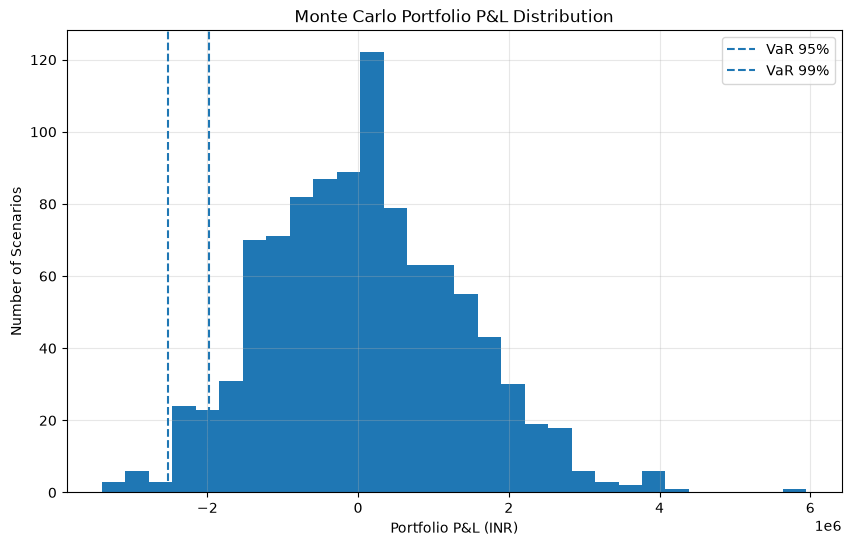

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    monte_carlo["PortfolioPnL_INR"],
    bins=30
)

plt.axvline(
    -var_95,
    linestyle="--",
    label="VaR 95%"
)

plt.axvline(
    -var_99,
    linestyle="--",
    label="VaR 99%"
)

plt.xlabel("Portfolio P&L (INR)")
plt.ylabel("Number of Scenarios")
plt.title("Monte Carlo Portfolio P&L Distribution")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

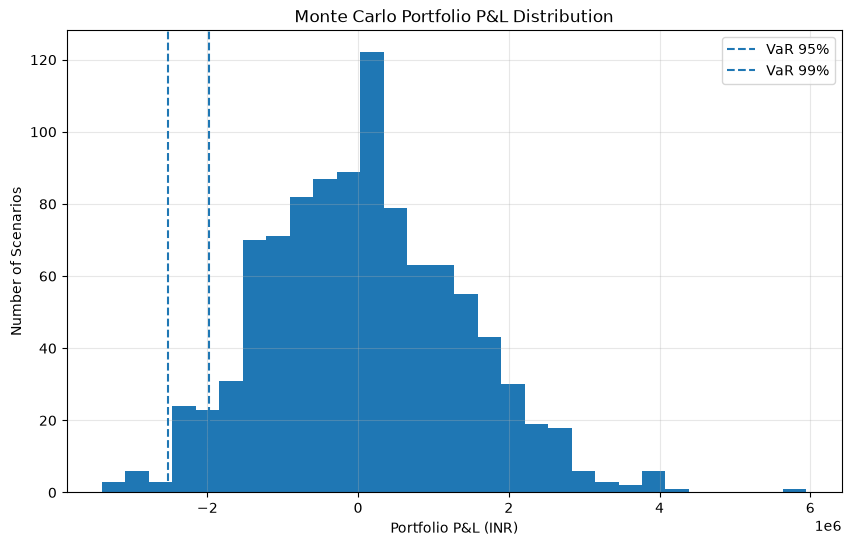

Monte Carlo P&L chart saved successfully.


In [102]:
plt.figure(figsize=(10, 6))

plt.hist(
    monte_carlo["PortfolioPnL_INR"],
    bins=30
)

plt.axvline(
    -var_95,
    linestyle="--",
    label="VaR 95%"
)

plt.axvline(
    -var_99,
    linestyle="--",
    label="VaR 99%"
)

plt.xlabel("Portfolio P&L (INR)")
plt.ylabel("Number of Scenarios")
plt.title("Monte Carlo Portfolio P&L Distribution")

plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "../outputs/monte_carlo_pnl_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Monte Carlo P&L chart saved successfully.")

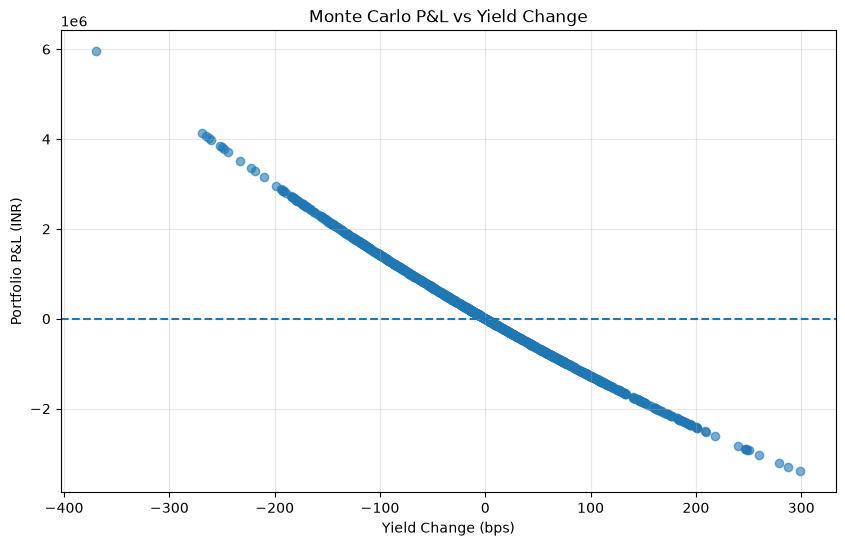

In [103]:
plt.figure(figsize=(10, 6))

plt.scatter(
    monte_carlo["YieldChange"] * 10000,
    monte_carlo["PortfolioPnL_INR"],
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Yield Change (bps)")
plt.ylabel("Portfolio P&L (INR)")
plt.title("Monte Carlo P&L vs Yield Change")

plt.grid(alpha=0.3)

plt.show()

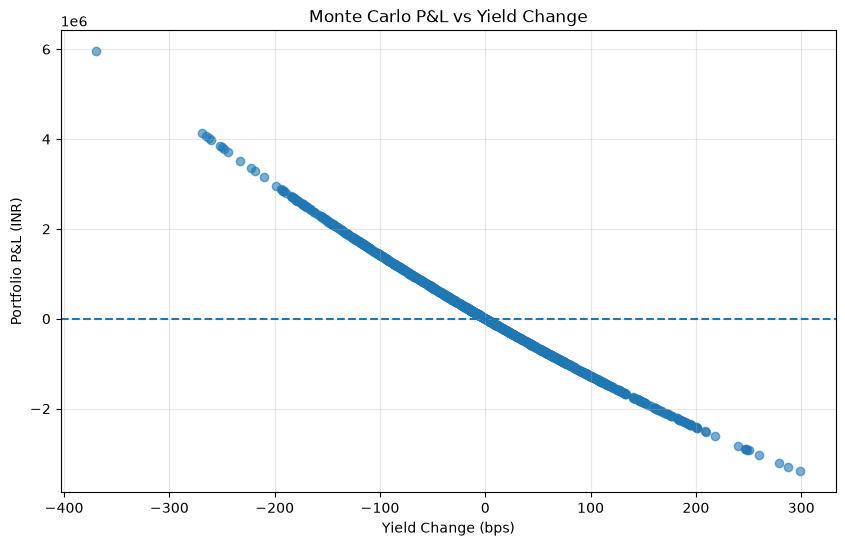

P&L vs Yield Change chart saved successfully.


In [104]:
plt.figure(figsize=(10, 6))

plt.scatter(
    monte_carlo["YieldChange"] * 10000,
    monte_carlo["PortfolioPnL_INR"],
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Yield Change (bps)")
plt.ylabel("Portfolio P&L (INR)")
plt.title("Monte Carlo P&L vs Yield Change")

plt.grid(alpha=0.3)

plt.savefig(
    "../outputs/monte_carlo_pnl_vs_yield.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("P&L vs Yield Change chart saved successfully.")

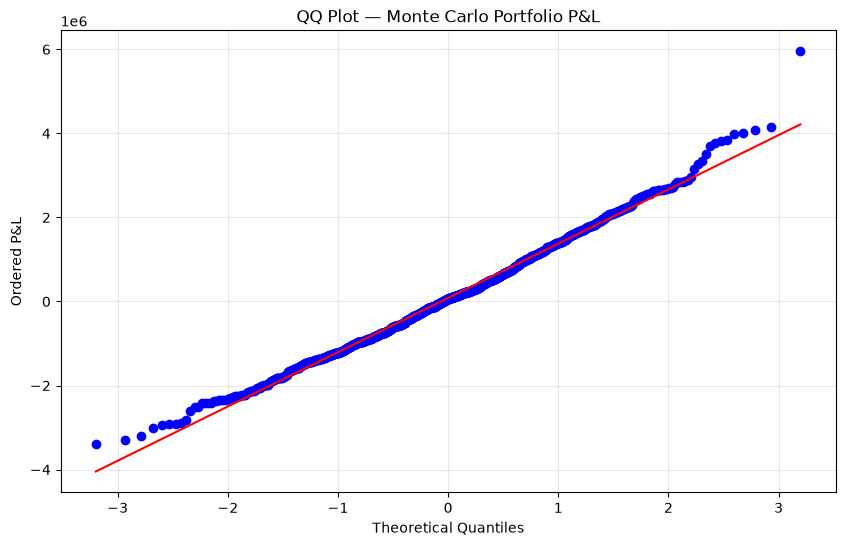

In [105]:
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

stats.probplot(
    monte_carlo["PortfolioPnL_INR"],
    dist="norm",
    plot=plt
)

plt.title("QQ Plot — Monte Carlo Portfolio P&L")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Ordered P&L")

plt.grid(alpha=0.3)

plt.show()

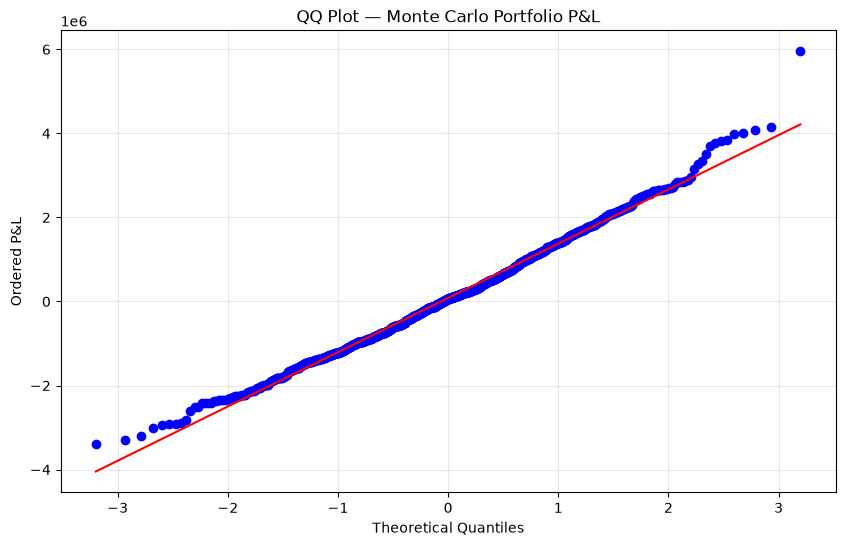

QQ plot saved successfully.


In [106]:
plt.figure(figsize=(10, 6))

stats.probplot(
    monte_carlo["PortfolioPnL_INR"],
    dist="norm",
    plot=plt
)

plt.title("QQ Plot — Monte Carlo Portfolio P&L")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Ordered P&L")

plt.grid(alpha=0.3)

plt.savefig(
    "../outputs/monte_carlo_qq_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("QQ plot saved successfully.")

In [107]:
extreme_shocks_bps = np.array([-200, 200])
extreme_shocks = extreme_shocks_bps / 10000

duration_convexity_comparison = []

for shock_bps, shock in zip(extreme_shocks_bps, extreme_shocks):

    duration_only_pnl = (
        -portfolio_modified_duration
        * shock
        * portfolio_market_value
    )

    duration_convexity_pnl = (
        portfolio_market_value
        * (
            -portfolio_modified_duration * shock
            + 0.5 * portfolio_convexity * (shock ** 2)
        )
    )

    duration_convexity_comparison.append({
        "Shock_bps": shock_bps,
        "Duration_Only_PnL_INR": duration_only_pnl,
        "Duration_Convexity_PnL_INR": duration_convexity_pnl
    })

duration_convexity_comparison = pd.DataFrame(
    duration_convexity_comparison
)

duration_convexity_comparison

,Shock_bps,Duration_Only_PnL_INR,Duration_Convexity_PnL_INR
0,-200,2.694990e+06,2.977505e+06
1,200,-2.694990e+06,-2.412476e+06


In [108]:
duration_convexity_comparison["Convexity_Effect_INR"] = (
    duration_convexity_comparison["Duration_Convexity_PnL_INR"]
    - duration_convexity_comparison["Duration_Only_PnL_INR"]
)

duration_convexity_comparison

,Shock_bps,Duration_Only_PnL_INR,Duration_Convexity_PnL_INR,Convexity_Effect_INR
0,-200,2.694990e+06,2.977505e+06,282514.645619
1,200,-2.694990e+06,-2.412476e+06,282514.645619


In [109]:
duration_convexity_comparison.to_csv(
    "../outputs/duration_vs_convexity_comparison.csv",
    index=False
)

print("Duration vs convexity comparison saved successfully.")

Duration vs convexity comparison saved successfully.


In [110]:
mc_final_check = pd.DataFrame({
    "Check": [
        "Number of Scenarios",
        "VaR 95%",
        "VaR 99%",
        "CVaR 95%",
        "CVaR 99%",
        "Maximum Gain",
        "Maximum Loss"
    ],
    "Result": [
        len(monte_carlo),
        var_95,
        var_99,
        cvar_95,
        cvar_99,
        max_gain,
        max_loss
    ]
})

mc_final_check

,Check,Result
0,Number of Scenarios,1.000000e+03
1,VaR 95%,1.976641e+06
2,VaR 99%,2.517219e+06
3,CVaR 95%,2.377145e+06
4,CVaR 99%,2.999459e+06
5,Maximum Gain,5.948525e+06
6,Maximum Loss,-3.399526e+06


In [111]:
assert len(monte_carlo) == 1000

print("Monte Carlo validation: PASSED")
print("Scenarios:", len(monte_carlo))

Monte Carlo validation: PASSED
Scenarios: 1000


In [112]:
mc_final_check.to_csv(
    "../outputs/monte_carlo_final_validation.csv",
    index=False
)

print("Monte Carlo section completed successfully.")

Monte Carlo section completed successfully.


In [113]:
parallel_vol_bps = 10
twist_vol_bps = 5
butterfly_vol_bps = 5

print("Parallel volatility:", parallel_vol_bps, "bps")
print("Twist volatility:", twist_vol_bps, "bps")
print("Butterfly volatility:", butterfly_vol_bps, "bps")

Parallel volatility: 10 bps
Twist volatility: 5 bps
Butterfly volatility: 5 bps


In [114]:
parallel_vol_bps = 10
twist_vol_bps = 5
butterfly_vol_bps = 5

print("Parallel volatility:", parallel_vol_bps, "bps")
print("Twist volatility:", twist_vol_bps, "bps")
print("Butterfly volatility:", butterfly_vol_bps, "bps")

Parallel volatility: 10 bps
Twist volatility: 5 bps
Butterfly volatility: 5 bps


In [115]:
correlation_matrix = np.array([
    [1.0, -0.3, 0.1],
    [-0.3, 1.0, 0.2],
    [0.1, 0.2, 1.0]
])

print(correlation_matrix)

[[ 1.  -0.3  0.1]
 [-0.3  1.   0.2]
 [ 0.1  0.2  1. ]]


In [116]:
cholesky_matrix = np.linalg.cholesky(correlation_matrix)

print("Cholesky matrix:")
print(cholesky_matrix)

Cholesky matrix:
[[ 1.          0.          0.        ]
 [-0.3         0.9539392   0.        ]
 [ 0.1         0.24110551  0.96533317]]


In [117]:
import numpy as np
np.random.seed(42)

number_of_scenarios = 1000

independent_factors = np.random.normal(
    size=(number_of_scenarios, 3)
)

correlated_factors = (
    independent_factors @ cholesky_matrix.T
)

print(
    "Generated scenarios:",
    correlated_factors.shape[0]
)

print(
    "Number of factors:",
    correlated_factors.shape[1]
)

Generated scenarios: 1000
Number of factors: 3


In [118]:
krd_tenors

array([ 0.25,  0.5 ,  1.  ,  2.  ,  3.  ,  5.  ,  7.  , 10.  , 20.  ,
       30.  ])

In [119]:
parallel_loading = np.ones(10)

twist_loading = np.array([
    1.0,
    0.9,
    0.8,
    0.6,
    0.4,
    0.0,
    -0.4,
    -0.6,
    -0.9,
    -1.0
])

butterfly_loading = np.array([
    -0.5,
    -0.6,
    -0.4,
    0.0,
    0.6,
    1.0,
    0.8,
    0.4,
    -0.2,
    -0.5
])

print("Factor loadings created successfully.")

Factor loadings created successfully.


In [120]:
three_factor_scenarios = pd.DataFrame({
    "Parallel_bps": correlated_factors[:, 0] * parallel_vol_bps,
    "Twist_bps": correlated_factors[:, 1] * twist_vol_bps,
    "Butterfly_bps": correlated_factors[:, 2] * butterfly_vol_bps
})

print("Three-factor scenarios created successfully.")
print("Number of scenarios:", len(three_factor_scenarios))

Three-factor scenarios created successfully.
Number of scenarios: 1000


In [121]:
scenario_krd_shocks = []

for _,row in three_factor_scenarios.iterrows():

    tenor_shock = (
        row["Parallel_bps"] * parallel_loading
        + row["Twist_bps"] * twist_loading
        + row["Butterfly_bps"] * butterfly_loading
    )

    scenario_krd_shocks.append(tenor_shock)

scenario_krd_shocks = np.array(scenario_krd_shocks)

print("Scenario shock matrix shape:",
      scenario_krd_shocks.shape)

Scenario shock matrix shape: (1000, 10)


In [122]:
portfolio_krd_values = portfolio_krd["PortfolioKRD"].values

three_factor_pnl = []

for i in range(number_of_scenarios):

    shock_decimal = scenario_krd_shocks[i] / 10000

    pnl = (
        -portfolio_market_value
        * np.sum(
            portfolio_krd_values * shock_decimal
        )
    )

    three_factor_pnl.append(pnl)

three_factor_scenarios["PortfolioPnL_INR"] = three_factor_pnl

print("Three-factor KRD P&L calculated successfully.")

Three-factor KRD P&L calculated successfully.


In [123]:
three_factor_scenarios[
    [
        "Parallel_bps",
        "Twist_bps",
        "Butterfly_bps",
        "PortfolioPnL_INR"
    ]
].head()

,Parallel_bps,Twist_bps,Butterfly_bps,PortfolioPnL_INR
0,4.967142,-1.404550,3.207852,-82680.028332
1,15.230299,-3.401385,-0.650864,-221488.321988
2,15.792128,1.291611,-0.551226,-204549.003830
3,5.425600,-3.024202,-2.535305,-82483.373033
4,2.419623,-9.488709,-10.511133,-55372.706211


In [124]:
three_factor_scenarios

,Parallel_bps,Twist_bps,Butterfly_bps,PortfolioPnL_INR
0,4.967142,-1.404550,3.207852,-82680.028332
1,15.230299,-3.401385,-0.650864,-221488.321988
2,15.792128,1.291611,-0.551226,-204549.003830
3,5.425600,-3.024202,-2.535305,-82483.373033
4,2.419623,-9.488709,-10.511133,-55372.706211
...,...,...,...,...
995,-9.600463,0.854785,-0.177275,134337.810658
996,-11.302037,13.198270,9.661368,196849.224930
997,6.021183,-0.559584,-0.636360,-82435.070374
998,-9.519185,1.797436,0.861531,135518.580859


In [125]:
three_factor_scenarios["Loss_INR"] = (
    -three_factor_scenarios["PortfolioPnL_INR"]
)

print("Loss column created successfully.")

Loss column created successfully.


In [126]:
three_var_95 = (
    three_factor_scenarios["Loss_INR"]
    .quantile(0.95)
)

three_var_99 = (
    three_factor_scenarios["Loss_INR"]
    .quantile(0.99)
)

print("3-Factor VaR 95%:", f"₹{three_var_95:,.2f}")
print("3-Factor VaR 99%:", f"₹{three_var_99:,.2f}")

3-Factor VaR 95%: ₹241,985.21
3-Factor VaR 99%: ₹333,413.47


In [127]:
three_cvar_95 = (
    three_factor_scenarios.loc[
        three_factor_scenarios["Loss_INR"] >= three_var_95,
        "Loss_INR"
    ].mean()
)

three_cvar_99 = (
    three_factor_scenarios.loc[
        three_factor_scenarios["Loss_INR"] >= three_var_99,
        "Loss_INR"
    ].mean()
)

print("3-Factor CVaR 95%:", f"₹{three_cvar_95:,.2f}")
print("3-Factor CVaR 99%:", f"₹{three_cvar_99:,.2f}")

3-Factor CVaR 95%: ₹301,758.63
3-Factor CVaR 99%: ₹396,581.50


In [128]:
var_comparison = pd.DataFrame({
    "Confidence_Level": [
        "95%",
        "99%"
    ],
    "Parallel_VaR_INR": [
        var_95,
        var_99
    ],
    "Three_Factor_VaR_INR": [
        three_var_95,
        three_var_99
    ]
})

var_comparison

,Confidence_Level,Parallel_VaR_INR,Three_Factor_VaR_INR
0,95%,1.976641e+06,241985.210145
1,99%,2.517219e+06,333413.465161


In [129]:
var_comparison["Difference_INR"] = (
    var_comparison["Three_Factor_VaR_INR"]
    - var_comparison["Parallel_VaR_INR"]
)

var_comparison["Difference_Percent"] = (
    var_comparison["Difference_INR"].abs()
    / var_comparison["Parallel_VaR_INR"].abs()
) * 100

var_comparison

,Confidence_Level,Parallel_VaR_INR,Three_Factor_VaR_INR,Difference_INR,Difference_Percent
0,95%,1.976641e+06,241985.210145,-1.734655e+06,87.757754
1,99%,2.517219e+06,333413.465161,-2.183806e+06,86.754692


In [130]:
var_comparison.to_csv(
    "../outputs/parallel_vs_three_factor_var.csv",
    index=False
)

print("VaR comparison saved successfully.")

VaR comparison saved successfully.


In [131]:
var_comparison.to_csv(
    "../outputs/parallel_vs_three_factor_var.csv",
    index=False
)

print("VaR comparison saved successfully.")

VaR comparison saved successfully.


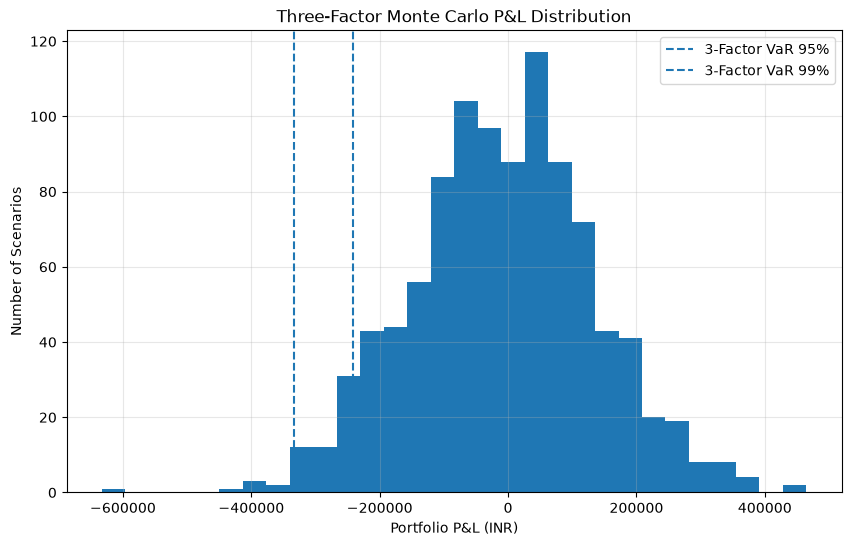

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    three_factor_scenarios["PortfolioPnL_INR"],
    bins=30
)

plt.axvline(
    -three_var_95,
    linestyle="--",
    label="3-Factor VaR 95%"
)

plt.axvline(
    -three_var_99,
    linestyle="--",
    label="3-Factor VaR 99%"
)

plt.xlabel("Portfolio P&L (INR)")
plt.ylabel("Number of Scenarios")
plt.title("Three-Factor Monte Carlo P&L Distribution")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

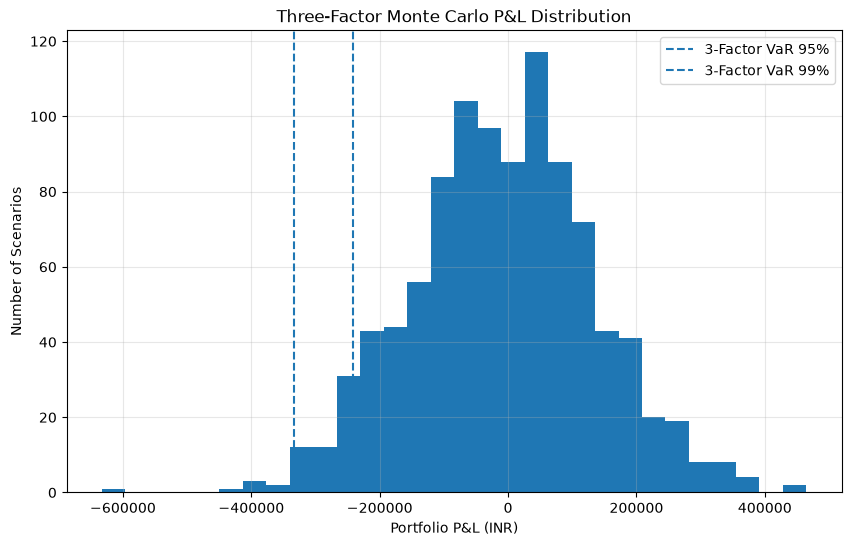

3-factor P&L distribution saved successfully.


In [133]:
plt.figure(figsize=(10, 6))

plt.hist(
    three_factor_scenarios["PortfolioPnL_INR"],
    bins=30
)

plt.axvline(
    -three_var_95,
    linestyle="--",
    label="3-Factor VaR 95%"
)

plt.axvline(
    -three_var_99,
    linestyle="--",
    label="3-Factor VaR 99%"
)

plt.xlabel("Portfolio P&L (INR)")
plt.ylabel("Number of Scenarios")
plt.title("Three-Factor Monte Carlo P&L Distribution")

plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "../outputs/three_factor_pnl_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("3-factor P&L distribution saved successfully.")

In [134]:
model_comparison = pd.DataFrame({
    "Metric": [
        "VaR 95%",
        "VaR 99%",
        "CVaR 95%",
        "CVaR 99%"
    ],
    "Parallel_Model_INR": [
        var_95,
        var_99,
        cvar_95,
        cvar_99
    ],
    "Three_Factor_Model_INR": [
        three_var_95,
        three_var_99,
        three_cvar_95,
        three_cvar_99
    ]
})

model_comparison

,Metric,Parallel_Model_INR,Three_Factor_Model_INR
0,VaR 95%,1.976641e+06,241985.210145
1,VaR 99%,2.517219e+06,333413.465161
2,CVaR 95%,2.377145e+06,301758.625817
3,CVaR 99%,2.999459e+06,396581.495263


In [135]:
model_comparison.to_csv(
    "../outputs/monte_carlo_model_comparison.csv",
    index=False
)

print("Monte Carlo model comparison saved successfully.")

Monte Carlo model comparison saved successfully.


In [136]:
twist_volatility_range = np.arange(3, 11)

sensitivity_results = []

for twist_vol in twist_volatility_range:

    # Generate independent random factors
    np.random.seed(42)

    independent = np.random.normal(
        size=(1000, 3)
    )

    # Apply correlation
    correlated = (
        independent @ cholesky_matrix.T
    )

    # Create scenario shocks
    parallel_shocks = (
        correlated[:, 0] * parallel_vol_bps
    )

    twist_shocks = (
        correlated[:, 1] * twist_vol
    )

    butterfly_shocks = (
        correlated[:, 2] * butterfly_vol_bps
    )

    # Calculate 10-tenor yield shocks
    pnl_list = []

    for i in range(1000):

        tenor_shock = (
            parallel_shocks[i] * parallel_loading
            + twist_shocks[i] * twist_loading
            + butterfly_shocks[i] * butterfly_loading
        )

        shock_decimal = tenor_shock / 10000

        pnl = (
            -portfolio_market_value
            * np.sum(
                portfolio_krd_values * shock_decimal
            )
        )

        pnl_list.append(pnl)

    pnl_series = pd.Series(pnl_list)

    loss_series = -pnl_series

    var_95_sensitivity = loss_series.quantile(0.95)
    var_99_sensitivity = loss_series.quantile(0.99)

    sensitivity_results.append({
        "Twist_Volatility_bps": twist_vol,
        "VaR_95_INR": var_95_sensitivity,
        "VaR_99_INR": var_99_sensitivity
    })

twist_sensitivity = pd.DataFrame(
    sensitivity_results
)

twist_sensitivity

,Twist_Volatility_bps,VaR_95_INR,VaR_99_INR
0,3,236607.047721,318568.715491
1,4,238879.076825,327177.891909
2,5,241985.210145,333413.465161
3,6,246710.673926,338892.228805
4,7,249631.686759,344370.992450
5,8,256546.708598,349849.756094
6,9,261421.070309,355416.081486
7,10,266396.492760,364031.124922


In [137]:
print(twist_sensitivity)

   Twist_Volatility_bps     VaR_95_INR     VaR_99_INR
0                     3  236607.047721  318568.715491
1                     4  238879.076825  327177.891909
2                     5  241985.210145  333413.465161
3                     6  246710.673926  338892.228805
4                     7  249631.686759  344370.992450
5                     8  256546.708598  349849.756094
6                     9  261421.070309  355416.081486
7                    10  266396.492760  364031.124922


In [138]:
twist_sensitivity.to_csv(
    "../outputs/twist_volatility_sensitivity.csv",
    index=False
)

print("Twist volatility sensitivity saved successfully.")

Twist volatility sensitivity saved successfully.


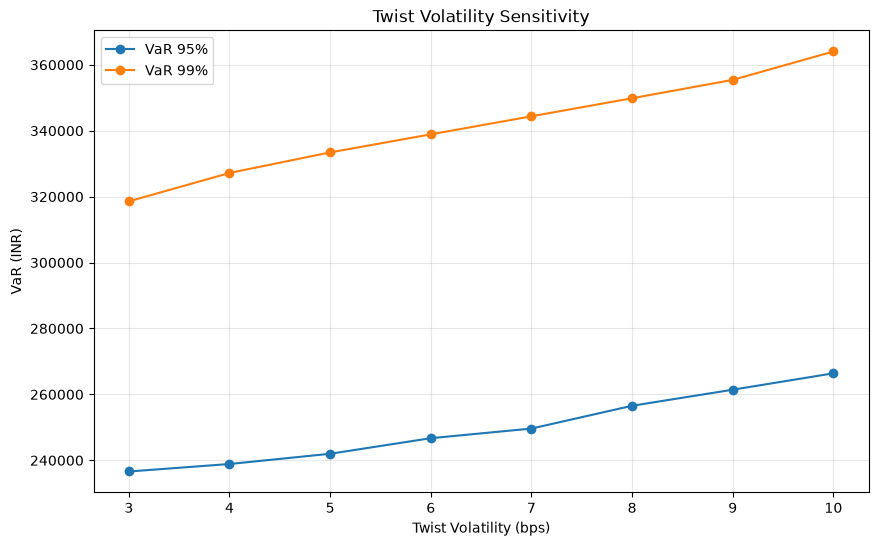

In [139]:
plt.figure(figsize=(10, 6))

plt.plot(
    twist_sensitivity["Twist_Volatility_bps"],
    twist_sensitivity["VaR_95_INR"],
    marker="o",
    label="VaR 95%"
)

plt.plot(
    twist_sensitivity["Twist_Volatility_bps"],
    twist_sensitivity["VaR_99_INR"],
    marker="o",
    label="VaR 99%"
)

plt.xlabel("Twist Volatility (bps)")
plt.ylabel("VaR (INR)")
plt.title("Twist Volatility Sensitivity")

plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "../outputs/twist_volatility_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [140]:
print("Number of scenarios:", len(three_factor_scenarios))
print(
    "Number of columns:",
    len(three_factor_scenarios.columns)
)

Number of scenarios: 1000
Number of columns: 5


In [141]:
three_factor_scenarios.isnull().sum()

Parallel_bps        0
Twist_bps           0
Butterfly_bps       0
PortfolioPnL_INR    0
Loss_INR            0
dtype: int64

In [142]:
day6_summary = pd.DataFrame({
    "Metric": [
        "Scenarios",
        "3-Factor VaR 95%",
        "3-Factor VaR 99%",
        "3-Factor CVaR 95%",
        "3-Factor CVaR 99%",
        "Maximum Gain",
        "Maximum Loss"
    ],
    "Value": [
        len(three_factor_scenarios),
        three_var_95,
        three_var_99,
        three_cvar_95,
        three_cvar_99,
        three_factor_scenarios["PortfolioPnL_INR"].max(),
        three_factor_scenarios["PortfolioPnL_INR"].min()
    ]
})

day6_summary

,Metric,Value
0,Scenarios,1000.000000
1,3-Factor VaR 95%,241985.210145
2,3-Factor VaR 99%,333413.465161
3,3-Factor CVaR 95%,301758.625817
4,3-Factor CVaR 99%,396581.495263
5,Maximum Gain,464741.763170
6,Maximum Loss,-632808.935286


In [143]:
day6_summary.to_csv(
    "../outputs/day6_three_factor_summary.csv",
    index=False
)

print("Day 6 summary saved successfully.")

Day 6 summary saved successfully.


In [144]:
three_factor_scenarios.to_csv(
    "../outputs/day6_three_factor_scenarios.csv",
    index=False
)

print("Day 6 scenario file saved successfully.")

Day 6 scenario file saved successfully.


In [145]:
assert len(three_factor_scenarios) == 1000
assert "PortfolioPnL_INR" in three_factor_scenarios.columns
assert "Loss_INR" in three_factor_scenarios.columns
assert len(twist_sensitivity) == 8

print("===================================")
print("DAY 6 VALIDATION: PASSED")
print("Scenarios: 1000")
print("Twist sensitivity: 3-10 bps")
print("===================================")

DAY 6 VALIDATION: PASSED
Scenarios: 1000
Twist sensitivity: 3-10 bps


In [146]:
three_factor_scenarios.to_csv(
    "../outputs/three_factor_monte_carlo_results.csv",
    index=False
)

print("three_factor_monte_carlo_results.csv saved successfully.")

three_factor_monte_carlo_results.csv saved successfully.


In [147]:
import os

output_files = [
    "monte_carlo_results.csv",
    "monte_carlo_summary.csv",
    "monte_carlo_var_cvar.csv",
    "risk_breach_summary.csv",
    "worst_monte_carlo_scenarios.csv",
    "monte_carlo_pnl_distribution.png",
    "monte_carlo_pnl_vs_yield.png",
    "monte_carlo_qq_plot.png",
    "duration_vs_convexity_comparison.csv",
    "three_factor_monte_carlo_results.csv",
    "monte_carlo_model_comparison.csv",
    "twist_volatility_sensitivity.csv",
    "twist_volatility_sensitivity.png",
    "day6_three_factor_summary.csv",
    "day6_three_factor_scenarios.csv"
]

for file in output_files:
    path = os.path.join("../outputs", file)

    if os.path.exists(path):
        print("✓", file)
    else:
        print("✗ MISSING:", file)

✓ monte_carlo_results.csv
✓ monte_carlo_summary.csv
✓ monte_carlo_var_cvar.csv
✓ risk_breach_summary.csv
✓ worst_monte_carlo_scenarios.csv
✓ monte_carlo_pnl_distribution.png
✓ monte_carlo_pnl_vs_yield.png
✓ monte_carlo_qq_plot.png
✓ duration_vs_convexity_comparison.csv
✓ three_factor_monte_carlo_results.csv
✓ monte_carlo_model_comparison.csv
✓ twist_volatility_sensitivity.csv
✓ twist_volatility_sensitivity.png
✓ day6_three_factor_summary.csv
✓ day6_three_factor_scenarios.csv


In [148]:
rbi_rate_cycle = pd.DataFrame({
    "Date": [
        "April 2022",
        "May 2022",
        "June 2022",
        "August 2022",
        "September 2022",
        "December 2022",
        "February 2023"
    ],
    "Repo_Rate_Percent": [
        4.00,
        4.40,
        4.90,
        5.40,
        5.90,
        6.25,
        6.50
    ]
})

rbi_rate_cycle

,Date,Repo_Rate_Percent
0,April 2022,4.00
1,May 2022,4.40
2,June 2022,4.90
3,August 2022,5.40
4,September 2022,5.90
5,December 2022,6.25
6,February 2023,6.50


In [149]:
rbi_yield_data = pd.DataFrame({
    "Date": [
        "31-Mar-2022",
        "30-Jun-2022",
        "30-Sep-2022",
        "31-Dec-2022",
        "31-Mar-2023"
    ],
    "10Y_GSec_Yield_Percent": [
        6.84,
        7.45,
        7.40,
        7.33,
        7.31
    ]
})

rbi_yield_data

,Date,10Y_GSec_Yield_Percent
0,31-Mar-2022,6.84
1,30-Jun-2022,7.45
2,30-Sep-2022,7.40
3,31-Dec-2022,7.33
4,31-Mar-2023,7.31


In [150]:
initial_yield = rbi_yield_data[
    "10Y_GSec_Yield_Percent"
].iloc[0]

final_yield = rbi_yield_data[
    "10Y_GSec_Yield_Percent"
].iloc[-1]

yield_change_percent = final_yield - initial_yield

yield_change_bps = yield_change_percent * 100

print("Initial 10Y yield:", initial_yield, "%")
print("Final 10Y yield:", final_yield, "%")
print("Yield change:", yield_change_bps, "bps")

Initial 10Y yield: 6.84 %
Final 10Y yield: 7.31 %
Yield change: 46.99999999999997 bps


In [151]:
delta_y_rbi = yield_change_bps / 10000

print("Δy =", delta_y_rbi)

Δy = 0.004699999999999998


In [152]:
duration_pnl_rbi = (
    -portfolio_market_value
    * portfolio_modified_duration
    * delta_y_rbi
)

print(
    "Duration P&L:",
    f"₹{duration_pnl_rbi:,.2f}"
)

Duration P&L: ₹-633,322.76


In [153]:
convexity_pnl_rbi = (
    0.5
    * portfolio_market_value
    * portfolio_convexity
    * (delta_y_rbi ** 2)
)

print(
    "Convexity P&L:",
    f"₹{convexity_pnl_rbi:,.2f}"
)

Convexity P&L: ₹15,601.87


In [154]:
estimated_pnl_rbi = (
    duration_pnl_rbi
    + convexity_pnl_rbi
)

print(
    "Estimated RBI Case P&L:",
    f"₹{estimated_pnl_rbi:,.2f}"
)

Estimated RBI Case P&L: ₹-617,720.89


In [155]:
rbi_case_summary = pd.DataFrame({
    "Metric": [
        "Initial 10Y Yield (%)",
        "Final 10Y Yield (%)",
        "Yield Change (bps)",
        "Portfolio Market Value (INR)",
        "Modified Duration",
        "Convexity",
        "Duration P&L (INR)",
        "Convexity P&L (INR)",
        "Estimated Total P&L (INR)"
    ],
    "Value": [
        initial_yield,
        final_yield,
        yield_change_bps,
        portfolio_market_value,
        portfolio_modified_duration,
        portfolio_convexity,
        duration_pnl_rbi,
        convexity_pnl_rbi,
        estimated_pnl_rbi
    ]
})

rbi_case_summary

,Metric,Value
0,Initial 10Y Yield (%),6.840000e+00
1,Final 10Y Yield (%),7.310000e+00
2,Yield Change (bps),4.700000e+01
3,Portfolio Market Value (INR),3.205935e+07
4,Modified Duration,4.203128e+00
5,Convexity,4.406120e+01
6,Duration P&L (INR),-6.333228e+05
7,Convexity P&L (INR),1.560187e+04
8,Estimated Total P&L (INR),-6.177209e+05


In [156]:
rbi_case_summary.to_csv(
    "../outputs/rbi_2022_23_case_summary.csv",
    index=False
)

print("RBI case study summary saved successfully.")

RBI case study summary saved successfully.


In [157]:
duration_contribution_rbi = (
    duration_pnl_rbi / estimated_pnl_rbi
) * 100

convexity_contribution_rbi = (
    convexity_pnl_rbi / estimated_pnl_rbi
) * 100

print(
    "Duration contribution:",
    f"{duration_contribution_rbi:.2f}%"
)

print(
    "Convexity contribution:",
    f"{convexity_contribution_rbi:.2f}%"
)

Duration contribution: 102.53%
Convexity contribution: -2.53%


In [158]:
rbi_decomposition = pd.DataFrame({
    "Component": [
        "Duration",
        "Convexity",
        "Total Estimated P&L"
    ],
    "P&L_INR": [
        duration_pnl_rbi,
        convexity_pnl_rbi,
        estimated_pnl_rbi
    ],
    "Contribution_Percent": [
        duration_contribution_rbi,
        convexity_contribution_rbi,
        100
    ]
})

rbi_decomposition

,Component,P&L_INR,Contribution_Percent
0,Duration,-633322.761797,102.525715
1,Convexity,15601.871304,-2.525715
2,Total Estimated P&L,-617720.890493,100.000000


In [159]:
rbi_decomposition.to_csv(
    "../outputs/rbi_duration_convexity_decomposition.csv",
    index=False
)

print(
    "RBI duration-convexity decomposition saved successfully."
)

RBI duration-convexity decomposition saved successfully.


In [160]:
print(
    "Duration P&L + Convexity P&L =",
    f"₹{(duration_pnl_rbi + convexity_pnl_rbi):,.2f}"
)

print(
    "Estimated Total P&L =",
    f"₹{estimated_pnl_rbi:,.2f}"
)

Duration P&L + Convexity P&L = ₹-617,720.89
Estimated Total P&L = ₹-617,720.89


In [161]:
rbi_actual_comparison = pd.DataFrame({
    "Metric": [
        "Initial 10Y G-Sec Yield (%)",
        "Final 10Y G-Sec Yield (%)",
        "Actual Yield Change (bps)",
        "Estimated Duration P&L (INR)",
        "Estimated Convexity P&L (INR)",
        "Estimated Total P&L (INR)",
        "Actual Portfolio P&L (INR)"
    ],
    "Value": [
        initial_yield,
        final_yield,
        yield_change_bps,
        duration_pnl_rbi,
        convexity_pnl_rbi,
        estimated_pnl_rbi,
        np.nan
    ]
})

rbi_actual_comparison

,Metric,Value
0,Initial 10Y G-Sec Yield (%),6.840000
1,Final 10Y G-Sec Yield (%),7.310000
2,Actual Yield Change (bps),47.000000
3,Estimated Duration P&L (INR),-633322.761797
4,Estimated Convexity P&L (INR),15601.871304
5,Estimated Total P&L (INR),-617720.890493
6,Actual Portfolio P&L (INR),NaN


In [162]:
rbi_actual_comparison["Note"] = [
    "RBI reported benchmark yield",
    "RBI reported benchmark yield",
    "Calculated from initial and final yield",
    "Duration approximation",
    "Convexity adjustment",
    "Duration + convexity estimate",
    "Not available for this specific portfolio"
]

rbi_actual_comparison

,Metric,Value,Note
0,Initial 10Y G-Sec Yield (%),6.840000,RBI reported benchmark yield
1,Final 10Y G-Sec Yield (%),7.310000,RBI reported benchmark yield
2,Actual Yield Change (bps),47.000000,Calculated from initial and final yield
3,Estimated Duration P&L (INR),-633322.761797,Duration approximation
4,Estimated Convexity P&L (INR),15601.871304,Convexity adjustment
5,Estimated Total P&L (INR),-617720.890493,Duration + convexity estimate
6,Actual Portfolio P&L (INR),NaN,Not available for this specific portfolio


In [163]:
rbi_actual_comparison.to_csv(
    "../outputs/rbi_actual_vs_estimated_pnl.csv",
    index=False
)

print("RBI actual vs estimated comparison saved successfully.")

RBI actual vs estimated comparison saved successfully.


In [164]:
print("RBI Case Study 1 completed.")
print("Yield change:", yield_change_bps, "bps")
print("Estimated P&L:", f"₹{estimated_pnl_rbi:,.2f}")
print("Actual portfolio P&L: Not available from case data")

RBI Case Study 1 completed.
Yield change: 46.99999999999997 bps
Estimated P&L: ₹-617,720.89
Actual portfolio P&L: Not available from case data


In [165]:
svb_case_data = pd.DataFrame({
    "Metric": [
        "Failure Date",
        "Assets at End-2022 (USD bn)",
        "AFS Securities Sold (USD bn)",
        "After-Tax Loss on Sale (USD bn)",
        "Deposit Outflow on March 9 (USD bn)"
    ],
    "Value": [
        "10-Mar-2023",
        209,
        21,
        1.8,
        42
    ]
})

svb_case_data

,Metric,Value
0,Failure Date,10-Mar-2023
1,Assets at End-2022 (USD bn),209
2,AFS Securities Sold (USD bn),21
3,After-Tax Loss on Sale (USD bn),1.8
4,Deposit Outflow on March 9 (USD bn),42


In [166]:
svb_case_data.to_csv(
    "../outputs/svb_case_background.csv",
    index=False
)

print("SVB case background saved successfully.")

SVB case background saved successfully.


In [167]:
svb_yield_data = pd.DataFrame({
    "Date": [
        "08-Mar-2023",
        "09-Mar-2023",
        "10-Mar-2023"
    ],
    "2Y_Treasury_Yield_Percent": [
        4.71,
        4.56,
        4.60
    ]
})

svb_yield_data

,Date,2Y_Treasury_Yield_Percent
0,08-Mar-2023,4.71
1,09-Mar-2023,4.56
2,10-Mar-2023,4.60


In [168]:
svb_initial_yield = (
    svb_yield_data[
        "2Y_Treasury_Yield_Percent"
    ].iloc[0]
)

svb_final_yield = (
    svb_yield_data[
        "2Y_Treasury_Yield_Percent"
    ].iloc[-1]
)

svb_yield_change_bps = (
    svb_final_yield - svb_initial_yield
) * 100

print("Initial 2Y yield:", svb_initial_yield, "%")
print("Final 2Y yield:", svb_final_yield, "%")
print("Yield change:", svb_yield_change_bps, "bps")

Initial 2Y yield: 4.71 %
Final 2Y yield: 4.6 %
Yield change: -11.000000000000032 bps


In [169]:
delta_y_svb = svb_yield_change_bps / 10000

print("SVB Δy =", delta_y_svb)

SVB Δy = -0.001100000000000003


In [170]:
duration_pnl_svb = (
    -portfolio_market_value
    * portfolio_modified_duration
    * delta_y_svb
)

print(
    "SVB Duration P&L:",
    f"₹{duration_pnl_svb:,.2f}"
)

SVB Duration P&L: ₹148,224.48


In [171]:
convexity_pnl_svb = (
    0.5
    * portfolio_market_value
    * portfolio_convexity
    * (delta_y_svb ** 2)
)

print(
    "SVB Convexity P&L:",
    f"₹{convexity_pnl_svb:,.2f}"
)

SVB Convexity P&L: ₹854.61


In [172]:
estimated_pnl_svb = (
    duration_pnl_svb
    + convexity_pnl_svb
)

print(
    "SVB Estimated Total P&L:",
    f"₹{estimated_pnl_svb:,.2f}"
)

SVB Estimated Total P&L: ₹149,079.08


In [173]:
svb_case_summary = pd.DataFrame({
    "Metric": [
        "Initial 2Y Treasury Yield (%)",
        "Final 2Y Treasury Yield (%)",
        "Yield Change (bps)",
        "Portfolio Market Value (INR)",
        "Modified Duration",
        "Convexity",
        "Duration P&L (INR)",
        "Convexity P&L (INR)",
        "Estimated Total P&L (INR)"
    ],
    "Value": [
        svb_initial_yield,
        svb_final_yield,
        svb_yield_change_bps,
        portfolio_market_value,
        portfolio_modified_duration,
        portfolio_convexity,
        duration_pnl_svb,
        convexity_pnl_svb,
        estimated_pnl_svb
    ]
})

svb_case_summary

,Metric,Value
0,Initial 2Y Treasury Yield (%),4.710000e+00
1,Final 2Y Treasury Yield (%),4.600000e+00
2,Yield Change (bps),-1.100000e+01
3,Portfolio Market Value (INR),3.205935e+07
4,Modified Duration,4.203128e+00
5,Convexity,4.406120e+01
6,Duration P&L (INR),1.482245e+05
7,Convexity P&L (INR),8.546068e+02
8,Estimated Total P&L (INR),1.490791e+05


In [174]:
svb_case_summary.to_csv(
    "../outputs/svb_duration_convexity_summary.csv",
    index=False
)

print("SVB duration-convexity summary saved successfully.")

SVB duration-convexity summary saved successfully.


In [175]:
duration_contribution_svb = (
    duration_pnl_svb / estimated_pnl_svb
) * 100

convexity_contribution_svb = (
    convexity_pnl_svb / estimated_pnl_svb
) * 100

print(
    "Duration contribution:",
    f"{duration_contribution_svb:.2f}%"
)

print(
    "Convexity contribution:",
    f"{convexity_contribution_svb:.2f}%"
)

Duration contribution: 99.43%
Convexity contribution: 0.57%


In [176]:
svb_decomposition = pd.DataFrame({
    "Component": [
        "Duration",
        "Convexity",
        "Total Estimated P&L"
    ],
    "P&L_INR": [
        duration_pnl_svb,
        convexity_pnl_svb,
        estimated_pnl_svb
    ],
    "Contribution_Percent": [
        duration_contribution_svb,
        convexity_contribution_svb,
        100
    ]
})

svb_decomposition

,Component,P&L_INR,Contribution_Percent
0,Duration,148224.476165,99.426743
1,Convexity,854.606803,0.573257
2,Total Estimated P&L,149079.082968,100.000000


In [177]:
svb_decomposition.to_csv(
    "../outputs/svb_duration_convexity_decomposition.csv",
    index=False
)

print(
    "SVB duration-convexity decomposition saved successfully."
)

SVB duration-convexity decomposition saved successfully.


In [178]:
print(
    "Duration P&L + Convexity P&L =",
    f"₹{(duration_pnl_svb + convexity_pnl_svb):,.2f}"
)

print(
    "Estimated Total P&L =",
    f"₹{estimated_pnl_svb:,.2f}"
)

Duration P&L + Convexity P&L = ₹149,079.08
Estimated Total P&L = ₹149,079.08


In [179]:
svb_actual_comparison = pd.DataFrame({
    "Metric": [
        "Initial 2Y Treasury Yield (%)",
        "Final 2Y Treasury Yield (%)",
        "Observed Yield Change (bps)",
        "Estimated Duration P&L (INR)",
        "Estimated Convexity P&L (INR)",
        "Estimated Total P&L (INR)",
        "SVB Actual AFS Securities Loss (USD bn)"
    ],
    "Value": [
        svb_initial_yield,
        svb_final_yield,
        svb_yield_change_bps,
        duration_pnl_svb,
        convexity_pnl_svb,
        estimated_pnl_svb,
        1.8
    ]
})

svb_actual_comparison

,Metric,Value
0,Initial 2Y Treasury Yield (%),4.710000
1,Final 2Y Treasury Yield (%),4.600000
2,Observed Yield Change (bps),-11.000000
3,Estimated Duration P&L (INR),148224.476165
4,Estimated Convexity P&L (INR),854.606803
5,Estimated Total P&L (INR),149079.082968
6,SVB Actual AFS Securities Loss (USD bn),1.800000


In [180]:
svb_actual_comparison["Explanation"] = [
    "Market yield at start of selected event window",
    "Market yield at end of selected event window",
    "Calculated from Treasury yields",
    "Duration-based project portfolio estimate",
    "Convexity adjustment to project portfolio estimate",
    "Duration + convexity estimated P&L",
    "Reported after-tax loss on SVB AFS securities sale"
]

svb_actual_comparison

,Metric,Value,Explanation
0,Initial 2Y Treasury Yield (%),4.710000,Market yield at start of selected event window
1,Final 2Y Treasury Yield (%),4.600000,Market yield at end of selected event window
2,Observed Yield Change (bps),-11.000000,Calculated from Treasury yields
3,Estimated Duration P&L (INR),148224.476165,Duration-based project portfolio estimate
4,Estimated Convexity P&L (INR),854.606803,Convexity adjustment to project portfolio esti...
5,Estimated Total P&L (INR),149079.082968,Duration + convexity estimated P&L
6,SVB Actual AFS Securities Loss (USD bn),1.800000,Reported after-tax loss on SVB AFS securities ...


In [181]:
svb_actual_comparison.to_csv(
    "../outputs/svb_actual_vs_estimated_pnl.csv",
    index=False
)

print("SVB actual vs estimated comparison saved successfully.")

SVB actual vs estimated comparison saved successfully.


In [182]:
print("SVB Case Study 2 completed.")
print(
    "Observed yield change:",
    svb_yield_change_bps,
    "bps"
)
print(
    "Estimated project P&L:",
    f"₹{estimated_pnl_svb:,.2f}"
)
print(
    "Reported SVB AFS loss:",
    "$1.8 billion"
)

SVB Case Study 2 completed.
Observed yield change: -11.000000000000032 bps
Estimated project P&L: ₹149,079.08
Reported SVB AFS loss: $1.8 billion


In [183]:
gilt_rally_data = pd.DataFrame({
    "Period": [
        "End-March 2019",
        "End-March 2020"
    ],
    "10Y_GSec_Yield_Percent": [
        7.47,
        6.14
    ]
})

gilt_rally_data

,Period,10Y_GSec_Yield_Percent
0,End-March 2019,7.47
1,End-March 2020,6.14


In [184]:
gilt_initial_yield = (
    gilt_rally_data[
        "10Y_GSec_Yield_Percent"
    ].iloc[0]
)

gilt_final_yield = (
    gilt_rally_data[
        "10Y_GSec_Yield_Percent"
    ].iloc[-1]
)

gilt_yield_change_bps = (
    gilt_final_yield - gilt_initial_yield
) * 100

print("Initial 10Y yield:", gilt_initial_yield, "%")
print("Final 10Y yield:", gilt_final_yield, "%")
print("Yield change:", gilt_yield_change_bps, "bps")

Initial 10Y yield: 7.47 %
Final 10Y yield: 6.14 %
Yield change: -133.0 bps


In [185]:
delta_y_gilt = gilt_yield_change_bps / 10000

print("Gilt rally Δy =", delta_y_gilt)

Gilt rally Δy = -0.0133


In [186]:
gilt_rally_data.to_csv(
    "../outputs/indian_gilt_rally_2019_20_data.csv",
    index=False
)

print("Indian gilt rally data saved successfully.")

Indian gilt rally data saved successfully.


In [187]:
duration_pnl_gilt = (
    -portfolio_market_value
    * portfolio_modified_duration
    * delta_y_gilt
)

print(
    "Gilt Rally Duration P&L:",
    f"₹{duration_pnl_gilt:,.2f}"
)

Gilt Rally Duration P&L: ₹1,792,168.67


In [188]:
convexity_pnl_gilt = (
    0.5
    * portfolio_market_value
    * portfolio_convexity
    * (delta_y_gilt ** 2)
)

print(
    "Gilt Rally Convexity P&L:",
    f"₹{convexity_pnl_gilt:,.2f}"
)

Gilt Rally Convexity P&L: ₹124,935.04


In [189]:
estimated_pnl_gilt = (
    duration_pnl_gilt
    + convexity_pnl_gilt
)

print(
    "Gilt Rally Estimated Total P&L:",
    f"₹{estimated_pnl_gilt:,.2f}"
)

Gilt Rally Estimated Total P&L: ₹1,917,103.71


In [190]:
gilt_case_summary = pd.DataFrame({
    "Metric": [
        "Initial 10Y G-Sec Yield (%)",
        "Final 10Y G-Sec Yield (%)",
        "Yield Change (bps)",
        "Portfolio Market Value (INR)",
        "Modified Duration",
        "Convexity",
        "Duration P&L (INR)",
        "Convexity P&L (INR)",
        "Estimated Total P&L (INR)"
    ],
    "Value": [
        gilt_initial_yield,
        gilt_final_yield,
        gilt_yield_change_bps,
        portfolio_market_value,
        portfolio_modified_duration,
        portfolio_convexity,
        duration_pnl_gilt,
        convexity_pnl_gilt,
        estimated_pnl_gilt
    ]
})

gilt_case_summary

,Metric,Value
0,Initial 10Y G-Sec Yield (%),7.470000e+00
1,Final 10Y G-Sec Yield (%),6.140000e+00
2,Yield Change (bps),-1.330000e+02
3,Portfolio Market Value (INR),3.205935e+07
4,Modified Duration,4.203128e+00
5,Convexity,4.406120e+01
6,Duration P&L (INR),1.792169e+06
7,Convexity P&L (INR),1.249350e+05
8,Estimated Total P&L (INR),1.917104e+06


In [191]:
gilt_case_summary.to_csv(
    "../outputs/indian_gilt_rally_duration_convexity.csv",
    index=False
)

print("Indian gilt rally duration-convexity summary saved successfully.")

Indian gilt rally duration-convexity summary saved successfully.


In [192]:
duration_contribution_gilt = (
    duration_pnl_gilt / estimated_pnl_gilt
) * 100

convexity_contribution_gilt = (
    convexity_pnl_gilt / estimated_pnl_gilt
) * 100

print(
    "Duration contribution:",
    f"{duration_contribution_gilt:.2f}%"
)

print(
    "Convexity contribution:",
    f"{convexity_contribution_gilt:.2f}%"
)

Duration contribution: 93.48%
Convexity contribution: 6.52%


In [193]:
gilt_decomposition = pd.DataFrame({
    "Component": [
        "Duration",
        "Convexity",
        "Total Estimated P&L"
    ],
    "P&L_INR": [
        duration_pnl_gilt,
        convexity_pnl_gilt,
        estimated_pnl_gilt
    ],
    "Contribution_Percent": [
        duration_contribution_gilt,
        convexity_contribution_gilt,
        100
    ]
})

gilt_decomposition

,Component,P&L_INR,Contribution_Percent
0,Duration,1.792169e+06,93.483136
1,Convexity,1.249350e+05,6.516864
2,Total Estimated P&L,1.917104e+06,100.000000


In [194]:
gilt_decomposition.to_csv(
    "../outputs/gilt_rally_duration_convexity_decomposition.csv",
    index=False
)

print(
    "Gilt rally duration-convexity decomposition saved successfully."
)

Gilt rally duration-convexity decomposition saved successfully.


In [195]:
print(
    "Duration P&L + Convexity P&L =",
    f"₹{(duration_pnl_gilt + convexity_pnl_gilt):,.2f}"
)

print(
    "Estimated Total P&L =",
    f"₹{estimated_pnl_gilt:,.2f}"
)

Duration P&L + Convexity P&L = ₹1,917,103.71
Estimated Total P&L = ₹1,917,103.71


In [196]:
gilt_actual_comparison = pd.DataFrame({
    "Metric": [
        "Initial 10Y G-Sec Yield (%)",
        "Final 10Y G-Sec Yield (%)",
        "Actual Yield Change (bps)",
        "Estimated Duration P&L (INR)",
        "Estimated Convexity P&L (INR)",
        "Estimated Total P&L (INR)",
        "Actual Portfolio P&L (INR)"
    ],
    "Value": [
        gilt_initial_yield,
        gilt_final_yield,
        gilt_yield_change_bps,
        duration_pnl_gilt,
        convexity_pnl_gilt,
        estimated_pnl_gilt,
        np.nan
    ]
})

gilt_actual_comparison

,Metric,Value
0,Initial 10Y G-Sec Yield (%),7.470000e+00
1,Final 10Y G-Sec Yield (%),6.140000e+00
2,Actual Yield Change (bps),-1.330000e+02
3,Estimated Duration P&L (INR),1.792169e+06
4,Estimated Convexity P&L (INR),1.249350e+05
5,Estimated Total P&L (INR),1.917104e+06
6,Actual Portfolio P&L (INR),NaN


In [197]:
gilt_actual_comparison["Explanation"] = [
    "10Y G-Sec yield at beginning of case period",
    "10Y G-Sec yield at end of case period",
    "Calculated from initial and final yield",
    "Duration-based estimated P&L",
    "Convexity adjustment",
    "Duration + convexity estimate",
    "Not available for this specific portfolio"
]

gilt_actual_comparison

,Metric,Value,Explanation
0,Initial 10Y G-Sec Yield (%),7.470000e+00,10Y G-Sec yield at beginning of case period
1,Final 10Y G-Sec Yield (%),6.140000e+00,10Y G-Sec yield at end of case period
2,Actual Yield Change (bps),-1.330000e+02,Calculated from initial and final yield
3,Estimated Duration P&L (INR),1.792169e+06,Duration-based estimated P&L
4,Estimated Convexity P&L (INR),1.249350e+05,Convexity adjustment
5,Estimated Total P&L (INR),1.917104e+06,Duration + convexity estimate
6,Actual Portfolio P&L (INR),NaN,Not available for this specific portfolio


In [198]:
gilt_actual_comparison.to_csv(
    "../outputs/gilt_rally_actual_vs_estimated_pnl.csv",
    index=False
)

print(
    "Gilt rally actual vs estimated comparison saved successfully."
)

Gilt rally actual vs estimated comparison saved successfully.


In [199]:
print("Gilt Rally Case Study 3 completed.")

print(
    "Yield change:",
    gilt_yield_change_bps,
    "bps"
)

print(
    "Estimated P&L:",
    f"₹{estimated_pnl_gilt:,.2f}"
)

print(
    "Actual portfolio P&L: Not available from case data"
)

Gilt Rally Case Study 3 completed.
Yield change: -133.0 bps
Estimated P&L: ₹1,917,103.71
Actual portfolio P&L: Not available from case data


In [200]:
case_study_comparison = pd.DataFrame({
    "Case_Study": [
        "RBI 2022-23 Rate Hike",
        "SVB Collapse",
        "Indian Gilt Rally 2019-20"
    ],
    "Yield_Change_bps": [
        yield_change_bps,
        svb_yield_change_bps,
        gilt_yield_change_bps
    ],
    "Duration_PnL_INR": [
        duration_pnl_rbi,
        duration_pnl_svb,
        duration_pnl_gilt
    ],
    "Convexity_PnL_INR": [
        convexity_pnl_rbi,
        convexity_pnl_svb,
        convexity_pnl_gilt
    ],
    "Estimated_Total_PnL_INR": [
        estimated_pnl_rbi,
        estimated_pnl_svb,
        estimated_pnl_gilt
    ]
})

case_study_comparison

,Case_Study,Yield_Change_bps,Duration_PnL_INR,Convexity_PnL_INR,Estimated_Total_PnL_INR
0,RBI 2022-23 Rate Hike,47.0,-6.333228e+05,15601.871304,-6.177209e+05
1,SVB Collapse,-11.0,1.482245e+05,854.606803,1.490791e+05
2,Indian Gilt Rally 2019-20,-133.0,1.792169e+06,124935.039159,1.917104e+06


In [201]:
case_study_comparison["Duration_Contribution_%"] = [
    duration_contribution_rbi,
    duration_contribution_svb,
    duration_contribution_gilt
]

case_study_comparison["Convexity_Contribution_%"] = [
    convexity_contribution_rbi,
    convexity_contribution_svb,
    convexity_contribution_gilt
]

case_study_comparison

,Case_Study,Yield_Change_bps,Duration_PnL_INR,Convexity_PnL_INR,Estimated_Total_PnL_INR,Duration_Contribution_%,Convexity_Contribution_%
0,RBI 2022-23 Rate Hike,47.0,-6.333228e+05,15601.871304,-6.177209e+05,102.525715,-2.525715
1,SVB Collapse,-11.0,1.482245e+05,854.606803,1.490791e+05,99.426743,0.573257
2,Indian Gilt Rally 2019-20,-133.0,1.792169e+06,124935.039159,1.917104e+06,93.483136,6.516864


In [202]:
case_study_comparison.to_csv(
    "../outputs/day7_case_study_comparison.csv",
    index=False
)

print("Day 7 case study comparison saved successfully.")

Day 7 case study comparison saved successfully.


In [203]:
display(
    case_study_comparison.round(2)
)

,Case_Study,Yield_Change_bps,Duration_PnL_INR,Convexity_PnL_INR,Estimated_Total_PnL_INR,Duration_Contribution_%,Convexity_Contribution_%
0,RBI 2022-23 Rate Hike,47.0,-633322.76,15601.87,-617720.89,102.53,-2.53
1,SVB Collapse,-11.0,148224.48,854.61,149079.08,99.43,0.57
2,Indian Gilt Rally 2019-20,-133.0,1792168.67,124935.04,1917103.71,93.48,6.52


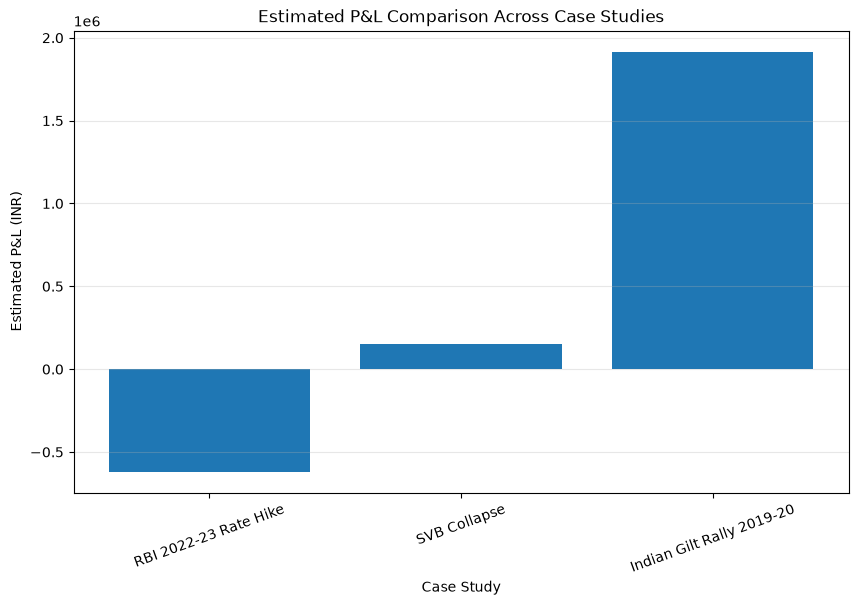

In [204]:
plt.figure(figsize=(10, 6))

plt.bar(
    case_study_comparison["Case_Study"],
    case_study_comparison["Estimated_Total_PnL_INR"]
)

plt.xlabel("Case Study")
plt.ylabel("Estimated P&L (INR)")
plt.title("Estimated P&L Comparison Across Case Studies")

plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "../outputs/day7_case_study_pnl_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

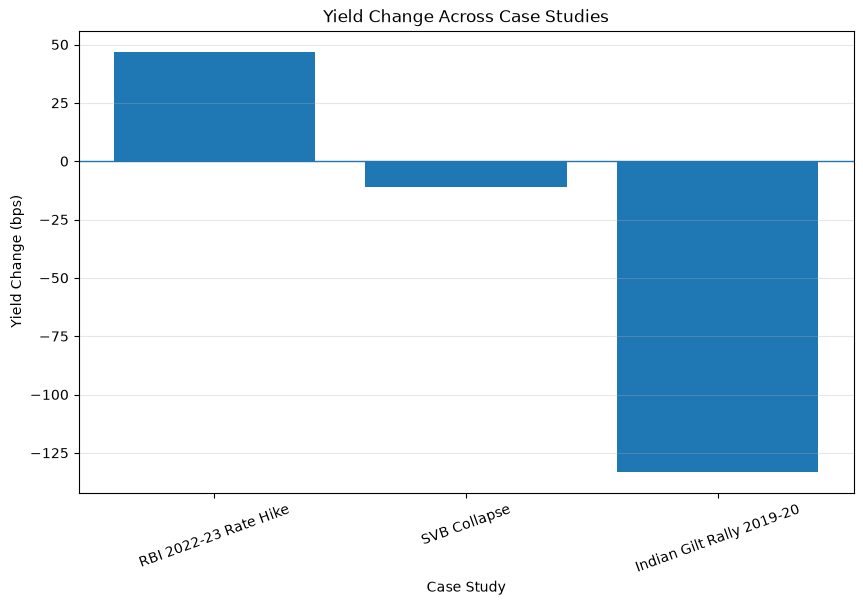

In [205]:
plt.figure(figsize=(10, 6))

plt.bar(
    case_study_comparison["Case_Study"],
    case_study_comparison["Yield_Change_bps"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Case Study")
plt.ylabel("Yield Change (bps)")
plt.title("Yield Change Across Case Studies")

plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "../outputs/day7_case_study_yield_change.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [206]:
import os

day7_files = [
    "day7_case_study_comparison.csv",
    "day7_case_study_pnl_comparison.png",
    "day7_case_study_yield_change.png",
    "rbi_2022_23_case_summary.csv",
    "rbi_duration_convexity_decomposition.csv",
    "rbi_actual_vs_estimated_pnl.csv",
    "svb_case_background.csv",
    "svb_duration_convexity_summary.csv",
    "svb_duration_convexity_decomposition.csv",
    "svb_actual_vs_estimated_pnl.csv",
    "indian_gilt_rally_2019_20_data.csv",
    "indian_gilt_rally_duration_convexity.csv",
    "gilt_rally_duration_convexity_decomposition.csv",
    "gilt_rally_actual_vs_estimated_pnl.csv"
]

for file in day7_files:
    if os.path.exists("../outputs/" + file):
        print("✓", file)
    else:
        print("✗ MISSING:", file)

✓ day7_case_study_comparison.csv
✓ day7_case_study_pnl_comparison.png
✓ day7_case_study_yield_change.png
✓ rbi_2022_23_case_summary.csv
✓ rbi_duration_convexity_decomposition.csv
✓ rbi_actual_vs_estimated_pnl.csv
✓ svb_case_background.csv
✓ svb_duration_convexity_summary.csv
✓ svb_duration_convexity_decomposition.csv
✓ svb_actual_vs_estimated_pnl.csv
✓ indian_gilt_rally_2019_20_data.csv
✓ indian_gilt_rally_duration_convexity.csv
✓ gilt_rally_duration_convexity_decomposition.csv
✓ gilt_rally_actual_vs_estimated_pnl.csv


In [207]:
print("===================================")
print("DAY 7 FINAL VALIDATION")
print("===================================")

print("RBI Case:", "✓")
print("SVB Case:", "✓")
print("Indian Gilt Rally Case:", "✓")

print(
    "Number of case studies:",
    len(case_study_comparison)
)

print(
    "Comparison table columns:",
    len(case_study_comparison.columns)
)

print("===================================")
print("DAY 7 VALIDATION COMPLETE")
print("===================================")

DAY 7 FINAL VALIDATION
RBI Case: ✓
SVB Case: ✓
Indian Gilt Rally Case: ✓
Number of case studies: 3
Comparison table columns: 7
DAY 7 VALIDATION COMPLETE


In [208]:
display(case_study_comparison.round(2))

,Case_Study,Yield_Change_bps,Duration_PnL_INR,Convexity_PnL_INR,Estimated_Total_PnL_INR,Duration_Contribution_%,Convexity_Contribution_%
0,RBI 2022-23 Rate Hike,47.0,-633322.76,15601.87,-617720.89,102.53,-2.53
1,SVB Collapse,-11.0,148224.48,854.61,149079.08,99.43,0.57
2,Indian Gilt Rally 2019-20,-133.0,1792168.67,124935.04,1917103.71,93.48,6.52


In [209]:
print(
    "Missing values:",
    case_study_comparison.isnull().sum().sum()
)

Missing values: 0


In [210]:
required_day7_files = [
    "day7_case_study_comparison.csv",
    "day7_case_study_pnl_comparison.png",
    "day7_case_study_yield_change.png"
]

for file in required_day7_files:
    exists = os.path.exists("../outputs/" + file)
    print(file, "✓" if exists else "✗")

day7_case_study_comparison.csv ✓
day7_case_study_pnl_comparison.png ✓
day7_case_study_yield_change.png ✓


In [211]:
print("Checking available portfolio columns...")

print(portfolio.columns.tolist())

Checking available portfolio columns...
['BondID', 'ISIN', 'Issuer', 'Sector', 'CreditRating', 'Currency', 'FaceValue', 'CouponRate', 'CouponFrequency', 'BondType', 'IssueDate', 'MaturityDate', 'ValuationDate', 'YearsToMaturity', 'OriginalMaturityYears', 'YieldToMaturity', 'CleanPrice', 'AccruedInterest', 'DirtyPrice', 'MacaulayDuration', 'ModifiedDuration', 'Convexity', 'DV01_Per100Face', 'EffectiveDuration', 'EffectiveConvexity', 'SpreadOverBenchmark_bps', 'OAS_bps', 'ZSpread_bps', 'KeyRateBucket', 'Quantity', 'MarketValue_LocalCcy', 'MarketValue_INR', 'PortfolioWeight', 'IsCallable', 'CallDate', 'IsPutable', 'IsFloatingRate', 'BenchmarkIndex', 'PriceChange_Up50bps', 'PriceChange_Dn50bps', 'PriceChange_Up100bps', 'PriceChange_Dn100bps', 'PriceChange_Up200bps', 'PriceChange_Dn200bps']


In [212]:
portfolio.columns.tolist()

['BondID',
 'ISIN',
 'Issuer',
 'Sector',
 'CreditRating',
 'Currency',
 'FaceValue',
 'CouponRate',
 'CouponFrequency',
 'BondType',
 'IssueDate',
 'MaturityDate',
 'ValuationDate',
 'YearsToMaturity',
 'OriginalMaturityYears',
 'YieldToMaturity',
 'CleanPrice',
 'AccruedInterest',
 'DirtyPrice',
 'MacaulayDuration',
 'ModifiedDuration',
 'Convexity',
 'DV01_Per100Face',
 'EffectiveDuration',
 'EffectiveConvexity',
 'SpreadOverBenchmark_bps',
 'OAS_bps',
 'ZSpread_bps',
 'KeyRateBucket',
 'Quantity',
 'MarketValue_LocalCcy',
 'MarketValue_INR',
 'PortfolioWeight',
 'IsCallable',
 'CallDate',
 'IsPutable',
 'IsFloatingRate',
 'BenchmarkIndex',
 'PriceChange_Up50bps',
 'PriceChange_Dn50bps',
 'PriceChange_Up100bps',
 'PriceChange_Dn100bps',
 'PriceChange_Up200bps',
 'PriceChange_Dn200bps']

In [213]:
ml_data = portfolio[
    [
        "CouponRate",
        "YearsToMaturity",
        "YieldToMaturity",
        "ModifiedDuration",
        "Convexity",
        "CleanPrice"
    ]
].copy()

print("ML dataset created successfully.")
print("Shape:", ml_data.shape)

ml_data.head()

ML dataset created successfully.
Shape: (300, 6)


,CouponRate,YearsToMaturity,YieldToMaturity,ModifiedDuration,Convexity,CleanPrice
0,0.0620,2.3135,0.0674,1.8488,4.4027,99.0052
1,0.0773,21.0048,0.0690,10.7591,170.9441,109.1347
2,0.0555,5.2676,0.0674,4.2725,21.7752,95.0190
3,0.0681,24.9117,0.0667,11.9397,215.5283,101.6783
4,0.0750,18.4066,0.0702,9.9940,142.4173,104.8627


In [214]:
print(ml_data.isnull().sum())

CouponRate          0
YearsToMaturity     0
YieldToMaturity     0
ModifiedDuration    0
Convexity           0
CleanPrice          0
dtype: int64


In [215]:
ml_data = ml_data.dropna().copy()

print("Final ML dataset shape:", ml_data.shape)

Final ML dataset shape: (300, 6)


In [216]:
ml_data = ml_data.rename(columns={
    "CouponRate": "coupon_rate",
    "YearsToMaturity": "maturity",
    "YieldToMaturity": "yield_rate",
    "ModifiedDuration": "duration",
    "Convexity": "convexity",
    "CleanPrice": "price"
})

ml_data.head()

,coupon_rate,maturity,yield_rate,duration,convexity,price
0,0.0620,2.3135,0.0674,1.8488,4.4027,99.0052
1,0.0773,21.0048,0.0690,10.7591,170.9441,109.1347
2,0.0555,5.2676,0.0674,4.2725,21.7752,95.0190
3,0.0681,24.9117,0.0667,11.9397,215.5283,101.6783
4,0.0750,18.4066,0.0702,9.9940,142.4173,104.8627


In [217]:
ml_data.to_csv(
    "../outputs/day8_ml_dataset.csv",
    index=False
)

print("Day 8 ML dataset saved successfully.")

Day 8 ML dataset saved successfully.


In [218]:
X = ml_data[
    [
        "coupon_rate",
        "maturity",
        "yield_rate",
        "duration",
        "convexity"
    ]
]

y = ml_data["price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (300, 5)
Target shape: (300,)


In [219]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 240
Testing samples: 60


In [220]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (240, 5)
X_test : (60, 5)
y_train: (240,)
y_test : (60,)


In [221]:
random_state=42

In [222]:
from sklearn.ensemble import RandomForestRegressor

print("Random Forest imported successfully.")

Random Forest imported successfully.


In [223]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

print("Random Forest model created.")

Random Forest model created.


In [224]:
rf_model.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [225]:
rf_predictions = rf_model.predict(X_test)

print("Random Forest predictions generated.")
print(rf_predictions[:10])

Random Forest predictions generated.
[ 99.440258   97.414217  100.4283135  84.989172   97.874585   98.4968515
 100.1521595  96.2841545  98.5531515  99.817042 ]


In [226]:
print("Actual test values:", len(y_test))
print("Predicted values:", len(rf_predictions))

Actual test values: 60
Predicted values: 60


In [227]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Evaluation metrics imported successfully.")

Evaluation metrics imported successfully.


In [228]:
rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAE :", rf_mae)
print("Random Forest R²  :", rf_r2)

Random Forest RMSE: 3.967501810372552
Random Forest MAE : 1.9426840083333263
Random Forest R²  : 0.6017449801009185


In [229]:
rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "RMSE": [rf_rmse],
    "MAE": [rf_mae],
    "R2": [rf_r2]
})

rf_results

,Model,RMSE,MAE,R2
0,Random Forest,3.967502,1.942684,0.601745


In [230]:
rf_results.to_csv(
    "../outputs/random_forest_results.csv",
    index=False
)

print("Random Forest evaluation results saved successfully.")

Random Forest evaluation results saved successfully.


In [231]:
try:
    import xgboost as xgb
    print("XGBoost is installed successfully.")
except ImportError:
    print("XGBoost is not installed.")

XGBoost is installed successfully.


In [232]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [233]:
import xgboost as xgb
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    objective="reg:squarederror"
)

print("XGBoost model created successfully.")

XGBoost model created successfully.


In [234]:
xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [235]:
xgb_predictions = xgb_model.predict(X_test)

print("XGBoost predictions generated.")
print(xgb_predictions[:10])

XGBoost predictions generated.
[100.02131   96.0993   100.447014  86.154205  96.55794   99.18823
 100.980156  95.832     98.08649   99.77754 ]


In [236]:
xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_predictions)
)

xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

print("XGBoost RMSE:", xgb_rmse)
print("XGBoost MAE :", xgb_mae)
print("XGBoost R²  :", xgb_r2)

XGBoost RMSE: 3.1936376304982304
XGBoost MAE : 1.6387884039306642
XGBoost R²  : 0.7419533262695774


In [237]:
xgb_results = pd.DataFrame({
    "Model": ["XGBoost"],
    "RMSE": [xgb_rmse],
    "MAE": [xgb_mae],
    "R2": [xgb_r2]
})

xgb_results

,Model,RMSE,MAE,R2
0,XGBoost,3.193638,1.638788,0.741953


In [238]:
xgb_results.to_csv(
    "../outputs/xgboost_results.csv",
    index=False
)

print("XGBoost evaluation results saved successfully.")

XGBoost evaluation results saved successfully.


In [239]:
ml_comparison = pd.concat(
    [rf_results, xgb_results],
    ignore_index=True
)

display(ml_comparison.round(4))

,Model,RMSE,MAE,R2
0,Random Forest,3.9675,1.9427,0.6017
1,XGBoost,3.1936,1.6388,0.7420


In [240]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

print("Neural Network libraries imported successfully.")

Neural Network libraries imported successfully.


In [241]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Feature scaling completed successfully.
Training data shape: (240, 5)
Testing data shape: (60, 5)


In [242]:
scaler.fit_transform(X_train)

array([[-1.15878546, -0.15502121, -1.24537399,  0.15135955, -0.25009433],
       [-0.12953021,  0.92547073,  0.15696467,  1.07178874,  0.74573648],
       [ 0.18111773,  2.13992603,  0.17002993,  1.61132   ,  1.84414678],
       ...,
       [ 0.27842914, -0.16584504,  0.23971136, -0.06455873, -0.35939471],
       [-1.99716063, -0.56570873, -1.7941152 , -0.55182922, -0.57175988],
       [ 0.37574054, -0.45102068,  0.0655078 , -0.40716253, -0.52048627]],
      shape=(240, 5))

In [243]:
scaler.transform(X_test)

array([[ 1.75307119e+00, -6.40128697e-01,  1.80318830e+00,
        -7.16977134e-01, -6.10847768e-01],
       [-1.48814713e+00, -4.58125354e-01, -1.65039726e+00,
        -3.39612946e-01, -5.00645064e-01],
       [ 6.56446518e-01, -7.12855898e-01,  4.18270004e-01,
        -8.04334853e-01, -6.28241401e-01],
       [-3.05439291e-01,  1.84155422e+00,  6.98628857e-02,
         1.65096031e+00,  1.78881953e+00],
       [-1.12510074e+00, -5.97846590e-01, -9.40517758e-01,
        -6.80149390e-01, -6.03729708e-01],
       [-1.02030384e+00, -6.00206579e-01, -1.19311292e+00,
        -6.79668610e-01, -6.03543534e-01],
       [ 9.40895240e-01, -6.38781897e-01,  8.05872924e-01,
        -7.05967273e-01, -6.08696835e-01],
       [ 1.51175762e-01,  6.24931685e-02,  2.78907157e-01,
         2.40399995e-01, -1.56359354e-01],
       [-2.27683735e-03, -6.56364433e-01,  2.09225733e-01,
        -8.00897276e-01, -6.27736249e-01],
       [ 9.33409747e-01, -7.52098438e-01,  9.49590860e-01,
        -9.12774772e-01

In [244]:
nn_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42
)

print("Neural Network model created successfully.")

Neural Network model created successfully.


In [245]:
nn_model.fit(
    X_train_scaled,
    y_train
)

print("Neural Network trained successfully.")

Neural Network trained successfully.


c:\Users\hp\OneDrive\Desktop\data analysis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [246]:
nn_predictions = nn_model.predict(
    X_test_scaled
)

print("Neural Network predictions generated.")
print(nn_predictions[:10])

Neural Network predictions generated.
[100.74402477  97.77941078 101.48552142  86.08006475  96.49500852
  99.5300035  100.57044058  95.86670473  97.38680726  99.50326831]


In [247]:
print("Actual test values:", len(y_test))
print("Predicted values:", len(nn_predictions))

Actual test values: 60
Predicted values: 60


In [248]:
nn_rmse = np.sqrt(
    mean_squared_error(y_test, nn_predictions)
)

nn_mae = mean_absolute_error(
    y_test,
    nn_predictions
)

nn_r2 = r2_score(
    y_test,
    nn_predictions
)

print("Neural Network RMSE:", nn_rmse)
print("Neural Network MAE :", nn_mae)
print("Neural Network R²  :", nn_r2)

Neural Network RMSE: 2.8956291661309566
Neural Network MAE : 1.5332184289124529
Neural Network R²  : 0.7878647323663234


In [249]:
nn_results = pd.DataFrame({
    "Model": ["Neural Network"],
    "RMSE": [nn_rmse],
    "MAE": [nn_mae],
    "R2": [nn_r2]
})

nn_results

,Model,RMSE,MAE,R2
0,Neural Network,2.895629,1.533218,0.787865


In [250]:
ml_comparison = pd.concat(
    [
        rf_results,
        xgb_results,
        nn_results
    ],
    ignore_index=True
)

display(ml_comparison.round(4))

,Model,RMSE,MAE,R2
0,Random Forest,3.9675,1.9427,0.6017
1,XGBoost,3.1936,1.6388,0.7420
2,Neural Network,2.8956,1.5332,0.7879


In [251]:
ml_comparison.to_csv(
    "../outputs/day8_ml_model_comparison.csv",
    index=False
)

print("Day 8 ML model comparison saved successfully.")

Day 8 ML model comparison saved successfully.


In [252]:
best_rmse_model = ml_comparison.loc[
    ml_comparison["RMSE"].idxmin(),
    "Model"
]

best_mae_model = ml_comparison.loc[
    ml_comparison["MAE"].idxmin(),
    "Model"
]

best_r2_model = ml_comparison.loc[
    ml_comparison["R2"].idxmax(),
    "Model"
]

print("Best model by RMSE:", best_rmse_model)
print("Best model by MAE :", best_mae_model)
print("Best model by R²  :", best_r2_model)

Best model by RMSE: Neural Network
Best model by MAE : Neural Network
Best model by R²  : Neural Network


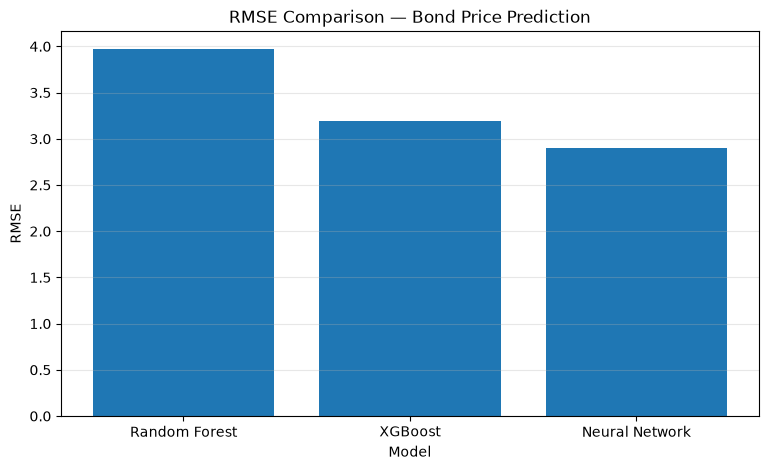

In [253]:
plt.figure(figsize=(9, 5))

plt.bar(
    ml_comparison["Model"],
    ml_comparison["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("RMSE Comparison — Bond Price Prediction")

plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "../outputs/day8_rmse_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

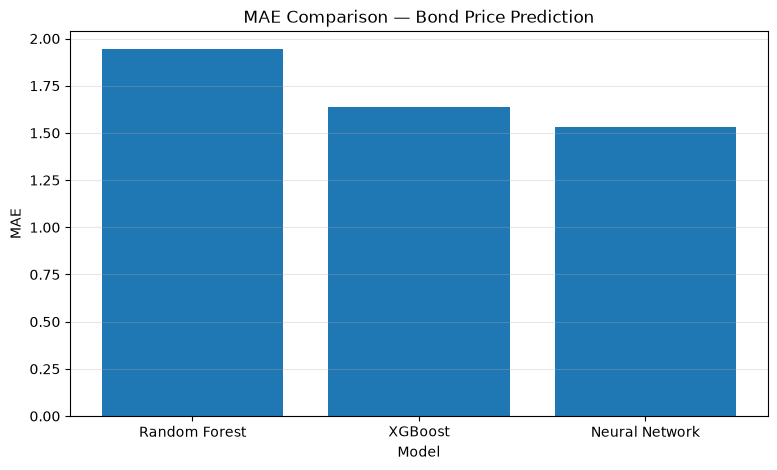

In [254]:
plt.figure(figsize=(9, 5))

plt.bar(
    ml_comparison["Model"],
    ml_comparison["MAE"]
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("MAE Comparison — Bond Price Prediction")

plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "../outputs/day8_mae_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

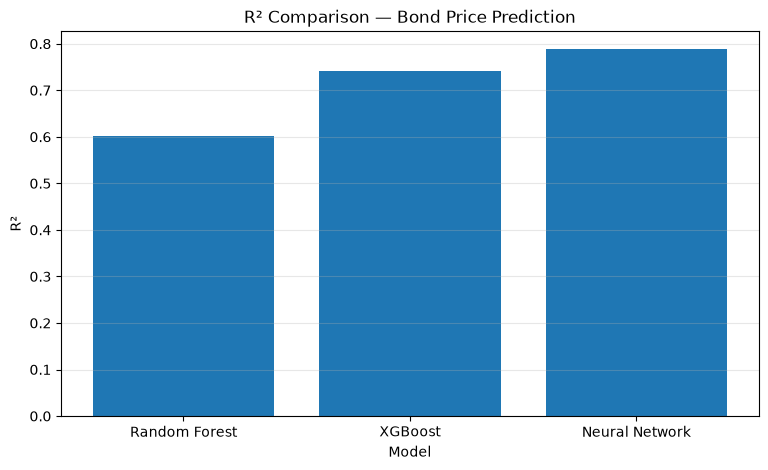

In [255]:
plt.figure(figsize=(9, 5))

plt.bar(
    ml_comparison["Model"],
    ml_comparison["R2"]
)

plt.xlabel("Model")
plt.ylabel("R²")
plt.title("R² Comparison — Bond Price Prediction")

plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "../outputs/day8_r2_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

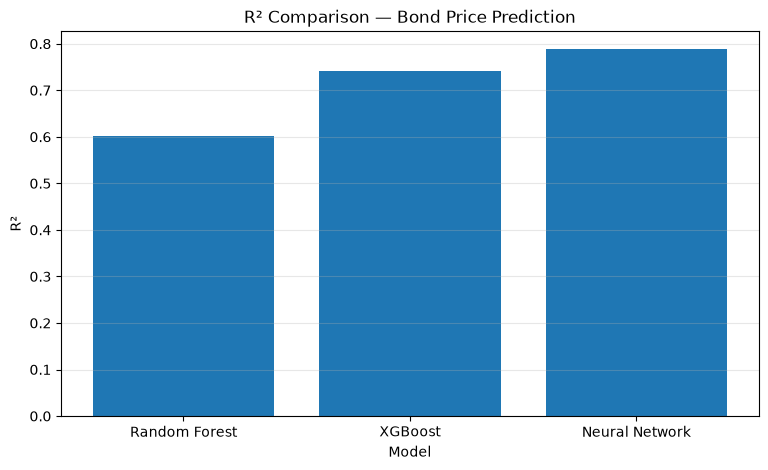

In [256]:
plt.figure(figsize=(9, 5))

plt.bar(
    ml_comparison["Model"],
    ml_comparison["R2"]
)

plt.xlabel("Model")
plt.ylabel("R²")
plt.title("R² Comparison — Bond Price Prediction")

plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "../outputs/day8_r2_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [257]:
import os

chart_files = [
    "day8_rmse_comparison.png",
    "day8_mae_comparison.png",
    "day8_r2_comparison.png"
]

for file in chart_files:
    if os.path.exists("../outputs/" + file):
        print("✓", file)
    else:
        print("✗ MISSING:", file)

✓ day8_rmse_comparison.png
✓ day8_mae_comparison.png
✓ day8_r2_comparison.png


In [258]:
rf_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_feature_importance = rf_feature_importance.sort_values(
    "Importance",
    ascending=False
)

rf_feature_importance

,Feature,Importance
0,coupon_rate,0.483330
3,duration,0.185991
2,yield_rate,0.148088
4,convexity,0.092638
1,maturity,0.089952


In [259]:
print(
    "Total feature importance:",
    rf_feature_importance["Importance"].sum()
)

Total feature importance: 1.0


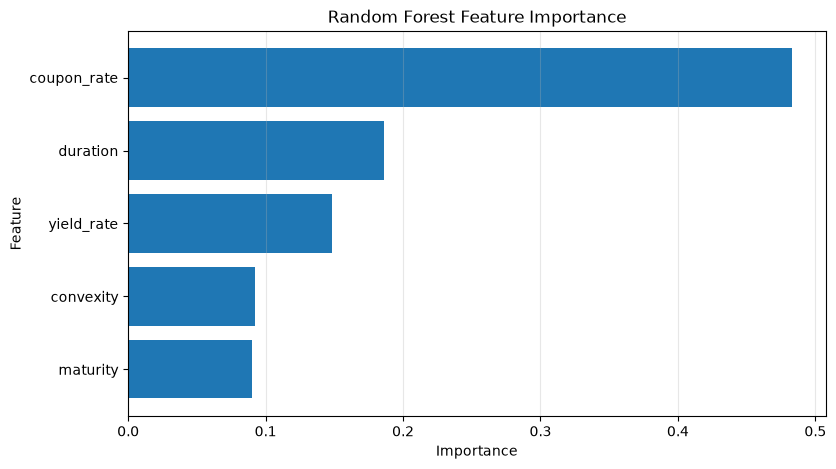

In [260]:
plt.figure(figsize=(9, 5))

plt.barh(
    rf_feature_importance["Feature"],
    rf_feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

plt.savefig(
    "../outputs/day8_random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [261]:
rf_feature_importance.to_csv(
    "../outputs/day8_random_forest_feature_importance.csv",
    index=False
)

print("Random Forest feature importance saved successfully.")

Random Forest feature importance saved successfully.


In [262]:
xgb_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_feature_importance = xgb_feature_importance.sort_values(
    "Importance",
    ascending=False
)

xgb_feature_importance

,Feature,Importance
3,duration,0.474503
0,coupon_rate,0.208375
2,yield_rate,0.134577
4,convexity,0.123652
1,maturity,0.058893


In [263]:
print(
    "Total XGBoost feature importance:",
    xgb_feature_importance["Importance"].sum()
)

Total XGBoost feature importance: 1.0


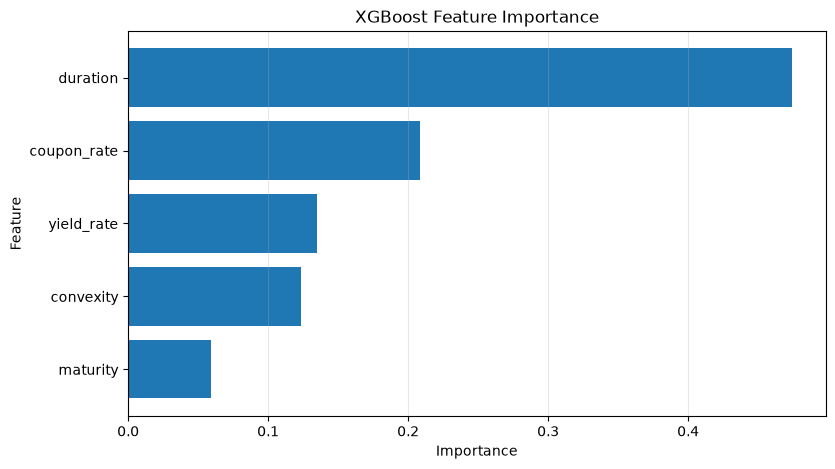

In [264]:
plt.figure(figsize=(9, 5))

plt.barh(
    xgb_feature_importance["Feature"],
    xgb_feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

plt.savefig(
    "../outputs/day8_xgboost_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [265]:
xgb_feature_importance.to_csv(
    "../outputs/day8_xgboost_feature_importance.csv",
    index=False
)

print("XGBoost feature importance saved successfully.")

XGBoost feature importance saved successfully.


In [266]:
feature_importance_comparison = pd.merge(
    rf_feature_importance,
    xgb_feature_importance,
    on="Feature",
    how="outer",
    suffixes=("_RandomForest", "_XGBoost")
)

feature_importance_comparison

,Feature,Importance_RandomForest,Importance_XGBoost
0,convexity,0.092638,0.123652
1,coupon_rate,0.483330,0.208375
2,duration,0.185991,0.474503
3,maturity,0.089952,0.058893
4,yield_rate,0.148088,0.134577


In [267]:
feature_importance_comparison = (
    feature_importance_comparison
    .sort_values(
        "Importance_RandomForest",
        ascending=False
    )
)

feature_importance_comparison

,Feature,Importance_RandomForest,Importance_XGBoost
1,coupon_rate,0.483330,0.208375
2,duration,0.185991,0.474503
4,yield_rate,0.148088,0.134577
0,convexity,0.092638,0.123652
3,maturity,0.089952,0.058893


In [268]:
feature_importance_comparison.to_csv(
    "../outputs/day8_feature_importance_comparison.csv",
    index=False
)

print("Feature importance comparison saved successfully.")

Feature importance comparison saved successfully.


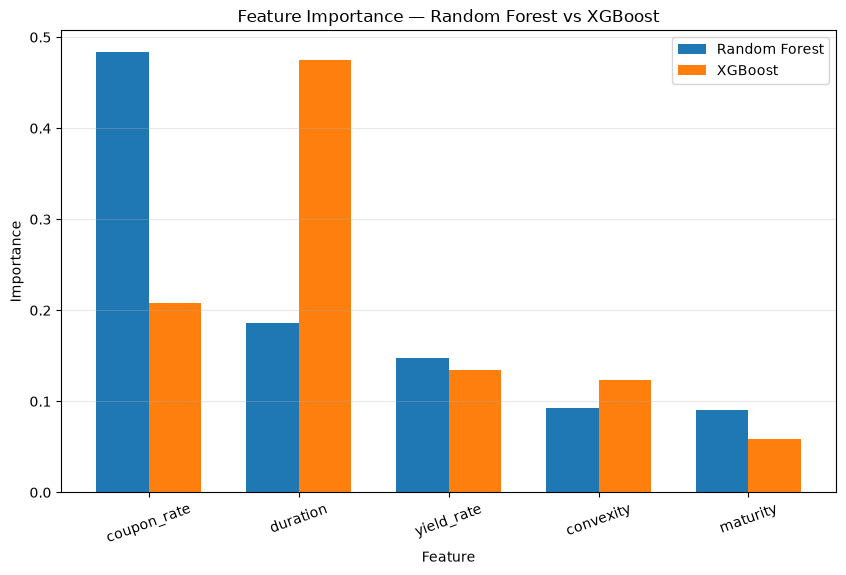

In [269]:
plt.figure(figsize=(10, 6))

x = np.arange(
    len(feature_importance_comparison["Feature"])
)

width = 0.35

plt.bar(
    x - width / 2,
    feature_importance_comparison["Importance_RandomForest"],
    width,
    label="Random Forest"
)

plt.bar(
    x + width / 2,
    feature_importance_comparison["Importance_XGBoost"],
    width,
    label="XGBoost"
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance — Random Forest vs XGBoost")

plt.xticks(
    x,
    feature_importance_comparison["Feature"],
    rotation=20
)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "../outputs/day8_feature_importance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [270]:
try:
    import shap
    print("SHAP is installed successfully.")
except ImportError:
    print("SHAP is not installed.")

c:\Users\hp\OneDrive\Desktop\data analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP is installed successfully.


In [271]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [272]:
import shap 
explainer = shap.TreeExplainer(xgb_model)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [273]:
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


C:\Users\hp\AppData\Local\Temp\ipykernel_1952\3639689651.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


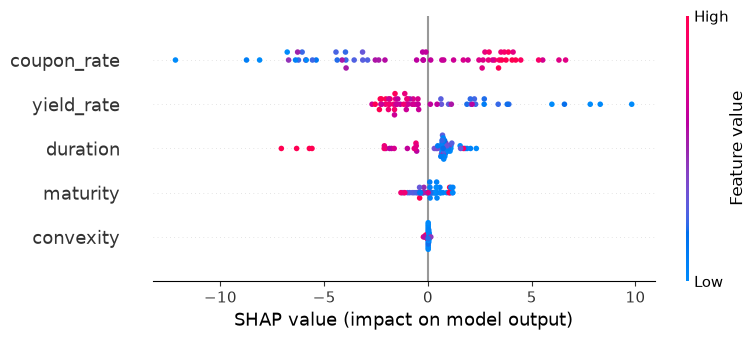

In [274]:
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.savefig(
    "../outputs/day8_shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_1952\3487734927.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


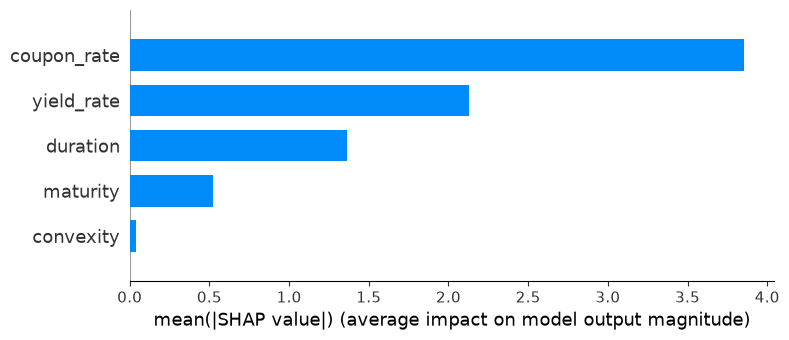

In [275]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.savefig(
    "../outputs/day8_shap_bar_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [276]:
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_Absolute_SHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

shap_importance

,Feature,Mean_Absolute_SHAP
0,coupon_rate,3.851416
2,yield_rate,2.130052
3,duration,1.362689
1,maturity,0.523924
4,convexity,0.037105


In [277]:
shap_importance.to_csv(
    "../outputs/day8_shap_feature_importance.csv",
    index=False
)

print("SHAP feature importance saved successfully.")

SHAP feature importance saved successfully.


In [278]:
ml_analytical_comparison = pd.DataFrame({
    "Actual_Price": y_test.values,
    "Random_Forest_Predicted": rf_predictions,
    "XGBoost_Predicted": xgb_predictions,
    "Neural_Network_Predicted": nn_predictions
})

ml_analytical_comparison.head()

,Actual_Price,Random_Forest_Predicted,XGBoost_Predicted,Neural_Network_Predicted
0,100.1401,99.440258,100.021309,100.744025
1,97.8610,97.414217,96.099297,97.779411
2,100.4584,100.428313,100.447014,101.485521
3,84.0622,84.989172,86.154205,86.080065
4,97.5288,97.874585,96.557938,96.495009


In [279]:
ml_analytical_comparison["RF_Error"] = (
    ml_analytical_comparison["Random_Forest_Predicted"]
    - ml_analytical_comparison["Actual_Price"]
)

ml_analytical_comparison["XGB_Error"] = (
    ml_analytical_comparison["XGBoost_Predicted"]
    - ml_analytical_comparison["Actual_Price"]
)

ml_analytical_comparison["NN_Error"] = (
    ml_analytical_comparison["Neural_Network_Predicted"]
    - ml_analytical_comparison["Actual_Price"]
)

ml_analytical_comparison.head()

,Actual_Price,Random_Forest_Predicted,XGBoost_Predicted,Neural_Network_Predicted,RF_Error,XGB_Error,NN_Error
0,100.1401,99.440258,100.021309,100.744025,-0.699842,-0.118791,0.603925
1,97.8610,97.414217,96.099297,97.779411,-0.446783,-1.761703,-0.081589
2,100.4584,100.428313,100.447014,101.485521,-0.030087,-0.011386,1.027121
3,84.0622,84.989172,86.154205,86.080065,0.926972,2.092005,2.017865
4,97.5288,97.874585,96.557938,96.495009,0.345785,-0.970862,-1.033791


In [280]:
comparison_errors = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "Neural Network"
    ],
    "Mean_Absolute_Error": [
        np.mean(np.abs(ml_analytical_comparison["RF_Error"])),
        np.mean(np.abs(ml_analytical_comparison["XGB_Error"])),
        np.mean(np.abs(ml_analytical_comparison["NN_Error"]))
    ]
})

comparison_errors

,Model,Mean_Absolute_Error
0,Random Forest,1.942684
1,XGBoost,1.638788
2,Neural Network,1.533218


In [281]:
ml_analytical_comparison.to_csv(
    "../outputs/day8_ml_vs_actual_price_comparison.csv",
    index=False
)

comparison_errors.to_csv(
    "../outputs/day8_ml_vs_analytical_error_comparison.csv",
    index=False
)

print("ML vs analytical price comparison saved successfully.")

ML vs analytical price comparison saved successfully.


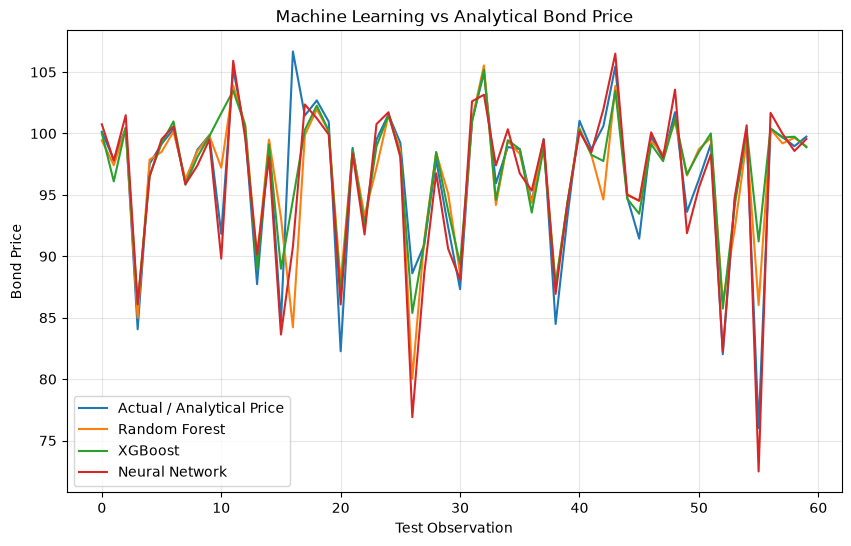

In [282]:
plt.figure(figsize=(10, 6))

plt.plot(
    ml_analytical_comparison["Actual_Price"].values,
    label="Actual / Analytical Price"
)

plt.plot(
    ml_analytical_comparison["Random_Forest_Predicted"].values,
    label="Random Forest"
)

plt.plot(
    ml_analytical_comparison["XGBoost_Predicted"].values,
    label="XGBoost"
)

plt.plot(
    ml_analytical_comparison["Neural_Network_Predicted"].values,
    label="Neural Network"
)

plt.xlabel("Test Observation")
plt.ylabel("Bond Price")
plt.title("Machine Learning vs Analytical Bond Price")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "../outputs/day8_ml_vs_analytical_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [283]:
print("===================================")
print("DAY 8 FINAL VALIDATION")
print("===================================")

print("Random Forest model:", "✓" if rf_model is not None else "✗")
print("XGBoost model:", "✓" if xgb_model is not None else "✗")
print("Neural Network model:", "✓" if nn_model is not None else "✗")

DAY 8 FINAL VALIDATION
Random Forest model: ✓
XGBoost model: ✓
Neural Network model: ✓


In [284]:
print("Number of ML models:", len(ml_comparison))
display(ml_comparison.round(4))

Number of ML models: 3


,Model,RMSE,MAE,R2
0,Random Forest,3.9675,1.9427,0.6017
1,XGBoost,3.1936,1.6388,0.7420
2,Neural Network,2.8956,1.5332,0.7879


In [285]:
import os

required_day8_files = [
    "day8_ml_dataset.csv",
    "random_forest_results.csv",
    "xgboost_results.csv",
    "day8_ml_model_comparison.csv",
    "day8_rmse_comparison.png",
    "day8_mae_comparison.png",
    "day8_r2_comparison.png",
    "day8_random_forest_feature_importance.csv",
    "day8_random_forest_feature_importance.png",
    "day8_xgboost_feature_importance.csv",
    "day8_xgboost_feature_importance.png",
    "day8_feature_importance_comparison.csv",
    "day8_feature_importance_comparison.png",
    "day8_shap_summary_plot.png",
    "day8_shap_bar_plot.png",
    "day8_shap_feature_importance.csv",
    "day8_ml_vs_actual_price_comparison.csv",
    "day8_ml_vs_analytical_error_comparison.csv",
    "day8_ml_vs_analytical_price.png"
]

for file in required_day8_files:
    if os.path.exists("../outputs/" + file):
        print("✓", file)
    else:
        print("✗ MISSING:", file)

✓ day8_ml_dataset.csv
✓ random_forest_results.csv
✓ xgboost_results.csv
✓ day8_ml_model_comparison.csv
✓ day8_rmse_comparison.png
✓ day8_mae_comparison.png
✓ day8_r2_comparison.png
✓ day8_random_forest_feature_importance.csv
✓ day8_random_forest_feature_importance.png
✓ day8_xgboost_feature_importance.csv
✓ day8_xgboost_feature_importance.png
✓ day8_feature_importance_comparison.csv
✓ day8_feature_importance_comparison.png
✓ day8_shap_summary_plot.png
✓ day8_shap_bar_plot.png
✓ day8_shap_feature_importance.csv
✓ day8_ml_vs_actual_price_comparison.csv
✓ day8_ml_vs_analytical_error_comparison.csv
✓ day8_ml_vs_analytical_price.png


In [286]:
yield_changes_bps = np.linspace(-200, 200, 50)

print("Number of scenarios:", len(yield_changes_bps))
print("First scenario:", yield_changes_bps[0], "bps")
print("Last scenario:", yield_changes_bps[-1], "bps")

Number of scenarios: 50
First scenario: -200.0 bps
Last scenario: 200.0 bps


In [287]:
yield_changes = yield_changes_bps / 10000

print(yield_changes[:5])

[-0.02       -0.01918367 -0.01836735 -0.01755102 -0.01673469]


In [288]:
day9_scenarios = pd.DataFrame({
    "Yield_Change_bps": yield_changes_bps,
    "Yield_Change": yield_changes
})

display(day9_scenarios.head())
display(day9_scenarios.tail())

,Yield_Change_bps,Yield_Change
0,-200.000000,-0.020000
1,-191.836735,-0.019184
2,-183.673469,-0.018367
3,-175.510204,-0.017551
4,-167.346939,-0.016735


,Yield_Change_bps,Yield_Change
45,167.346939,0.016735
46,175.510204,0.017551
47,183.673469,0.018367
48,191.836735,0.019184
49,200.000000,0.020000


In [289]:
day9_scenarios.to_csv(
    "../outputs/day9_yield_scenarios.csv",
    index=False
)

print("Day 9 yield scenarios saved successfully.")

Day 9 yield scenarios saved successfully.


In [290]:
base_bond = portfolio.iloc[0]

base_price = base_bond["CleanPrice"]
base_duration = base_bond["ModifiedDuration"]
base_convexity = base_bond["Convexity"]
base_yield = base_bond["YieldToMaturity"]

print("Base Price:", base_price)
print("Base Yield:", base_yield)
print("Base Duration:", base_duration)
print("Base Convexity:", base_convexity)

Base Price: 99.0052
Base Yield: 0.0674
Base Duration: 1.8488
Base Convexity: 4.4027


In [291]:
analytical_price_change = (
    -base_duration * yield_changes
    + 0.5 * base_convexity * (yield_changes ** 2)
) * base_price

print("Analytical price changes calculated.")
print(analytical_price_change[:5])

Analytical price changes calculated.
[3.74799431 3.5916019  3.43549996 3.2796885  3.12416751]


In [292]:
analytical_price_change = (
    -base_duration * yield_changes
    + 0.5 * base_convexity * (yield_changes ** 2)
) * base_price

print("Analytical price changes calculated.")
print(analytical_price_change[:5])

Analytical price changes calculated.
[3.74799431 3.5916019  3.43549996 3.2796885  3.12416751]


In [293]:
analytical_price = (
    base_price + analytical_price_change
)

print("Analytical prices calculated.")
print(analytical_price[:5])

Analytical prices calculated.
[102.75319431 102.5968019  102.44069996 102.2848885  102.12936751]


In [294]:
day9_scenarios["Analytical_Price_Change"] = (
    analytical_price_change
)

day9_scenarios["Analytical_Price"] = (
    analytical_price
)

display(day9_scenarios.head())

,Yield_Change_bps,Yield_Change,Analytical_Price_Change,Analytical_Price
0,-200.000000,-0.020000,3.747994,102.753194
1,-191.836735,-0.019184,3.591602,102.596802
2,-183.673469,-0.018367,3.435500,102.440700
3,-175.510204,-0.017551,3.279688,102.284888
4,-167.346939,-0.016735,3.124168,102.129368


In [295]:
display(
    day9_scenarios[
        [
            "Yield_Change_bps",
            "Analytical_Price_Change",
            "Analytical_Price"
        ]
    ].head()
)

display(
    day9_scenarios[
        [
            "Yield_Change_bps",
            "Analytical_Price_Change",
            "Analytical_Price"
        ]
    ].tail()
)

,Yield_Change_bps,Analytical_Price_Change,Analytical_Price
0,-200.000000,3.747994,102.753194
1,-191.836735,3.591602,102.596802
2,-183.673469,3.435500,102.440700
3,-175.510204,3.279688,102.284888
4,-167.346939,3.124168,102.129368


,Yield_Change_bps,Analytical_Price_Change,Analytical_Price
45,167.346939,-3.002096,96.003104
46,175.510204,-3.145418,95.859782
47,183.673469,-3.288448,95.716752
48,191.836735,-3.431189,95.574011
49,200.000000,-3.573638,95.431562


In [296]:
day9_scenarios.to_csv(
    "../outputs/day9_analytical_sensitivity.csv",
    index=False
)

print("Day 9 analytical sensitivity results saved successfully.")

Day 9 analytical sensitivity results saved successfully.


In [297]:
scenario_features = pd.DataFrame({
    "coupon_rate": [base_bond["CouponRate"]] * len(yield_changes),
    "maturity": [base_bond["YearsToMaturity"]] * len(yield_changes),
    "yield_rate": [
        base_yield + change for change in yield_changes
    ],
    "duration": [base_bond["ModifiedDuration"]] * len(yield_changes),
    "convexity": [base_bond["Convexity"]] * len(yield_changes)
})

print("Scenario feature dataset created.")
print("Shape:", scenario_features.shape)

scenario_features.head()

Scenario feature dataset created.
Shape: (50, 5)


,coupon_rate,maturity,yield_rate,duration,convexity
0,0.062,2.3135,0.047400,1.8488,4.4027
1,0.062,2.3135,0.048216,1.8488,4.4027
2,0.062,2.3135,0.049033,1.8488,4.4027
3,0.062,2.3135,0.049849,1.8488,4.4027
4,0.062,2.3135,0.050665,1.8488,4.4027


In [298]:
rf_scenario_predictions = rf_model.predict(
    scenario_features
)

print("Random Forest scenario predictions created.")
print(rf_scenario_predictions[:5])

Random Forest scenario predictions created.
[98.8417865 98.8417865 98.8417865 98.837353  98.837353 ]


In [299]:
xgb_scenario_predictions = xgb_model.predict(
    scenario_features
)

print("XGBoost scenario predictions created.")
print(xgb_scenario_predictions[:5])

XGBoost scenario predictions created.
[99.36273 99.36273 99.36273 99.36273 99.36273]


In [300]:
scenario_features_scaled = scaler.transform(
    scenario_features
)

nn_scenario_predictions = nn_model.predict(
    scenario_features_scaled
)

print("Neural Network scenario predictions created.")
print(nn_scenario_predictions[:5])

Neural Network scenario predictions created.
[108.30691596 107.89271633 107.55432997 107.22184328 106.825975  ]


In [301]:
day9_scenarios["RF_Price"] = rf_scenario_predictions

day9_scenarios["XGB_Price"] = xgb_scenario_predictions

day9_scenarios["NN_Price"] = nn_scenario_predictions

display(
    day9_scenarios[
        [
            "Yield_Change_bps",
            "Analytical_Price",
            "RF_Price",
            "XGB_Price",
            "NN_Price"
        ]
    ].head(10)
)

,Yield_Change_bps,Analytical_Price,RF_Price,XGB_Price,NN_Price
0,-200.000000,102.753194,98.841786,99.362732,108.306916
1,-191.836735,102.596802,98.841786,99.362732,107.892716
2,-183.673469,102.440700,98.841786,99.362732,107.554330
3,-175.510204,102.284888,98.837353,99.362732,107.221843
4,-167.346939,102.129368,98.837353,99.362732,106.825975
5,-159.183673,101.974137,98.837353,99.362732,106.430107
6,-151.020408,101.819197,98.837353,99.362732,106.052437
7,-142.857143,101.664547,98.832523,99.362732,105.687833
8,-134.693878,101.510188,98.835225,99.362732,105.264974
9,-126.530612,101.356120,98.831150,99.362732,104.842114


In [302]:
print("Analytical scenarios:", len(day9_scenarios))
print("RF predictions:", len(rf_scenario_predictions))
print("XGB predictions:", len(xgb_scenario_predictions))
print("NN predictions:", len(nn_scenario_predictions))

Analytical scenarios: 50
RF predictions: 50
XGB predictions: 50
NN predictions: 50


In [303]:
day9_scenarios.to_csv(
    "../outputs/day9_ml_sensitivity_predictions.csv",
    index=False
)

print("Day 9 ML sensitivity predictions saved successfully.")

Day 9 ML sensitivity predictions saved successfully.


In [304]:
day9_scenarios["RF_Price_Change"] = (
    day9_scenarios["RF_Price"] - base_price
)

day9_scenarios["XGB_Price_Change"] = (
    day9_scenarios["XGB_Price"] - base_price
)

day9_scenarios["NN_Price_Change"] = (
    day9_scenarios["NN_Price"] - base_price
)

print("ML price changes calculated successfully.")

ML price changes calculated successfully.


In [305]:
display(
    day9_scenarios[
        [
            "Yield_Change_bps",
            "Analytical_Price_Change",
            "RF_Price_Change",
            "XGB_Price_Change",
            "NN_Price_Change"
        ]
    ].head(10)
)

,Yield_Change_bps,Analytical_Price_Change,RF_Price_Change,XGB_Price_Change,NN_Price_Change
0,-200.000000,3.747994,-0.163414,0.357529,9.301716
1,-191.836735,3.591602,-0.163414,0.357529,8.887516
2,-183.673469,3.435500,-0.163414,0.357529,8.549130
3,-175.510204,3.279688,-0.167847,0.357529,8.216643
4,-167.346939,3.124168,-0.167847,0.357529,7.820775
5,-159.183673,2.968937,-0.167847,0.357529,7.424907
6,-151.020408,2.813997,-0.167847,0.357529,7.047237
7,-142.857143,2.659347,-0.172677,0.357529,6.682633
8,-134.693878,2.504988,-0.169975,0.357529,6.259774
9,-126.530612,2.350920,-0.174050,0.357529,5.836914


In [306]:
day9_scenarios["Analytical_Price_Change_pct"] = (
    day9_scenarios["Analytical_Price_Change"]
    / base_price
) * 100

day9_scenarios["RF_Price_Change_pct"] = (
    day9_scenarios["RF_Price_Change"]
    / base_price
) * 100

day9_scenarios["XGB_Price_Change_pct"] = (
    day9_scenarios["XGB_Price_Change"]
    / base_price
) * 100

day9_scenarios["NN_Price_Change_pct"] = (
    day9_scenarios["NN_Price_Change"]
    / base_price
) * 100

In [307]:
display(
    day9_scenarios[
        [
            "Yield_Change_bps",
            "Analytical_Price_Change_pct",
            "RF_Price_Change_pct",
            "XGB_Price_Change_pct",
            "NN_Price_Change_pct"
        ]
    ].round(4)
)

,Yield_Change_bps,Analytical_Price_Change_pct,RF_Price_Change_pct,XGB_Price_Change_pct,NN_Price_Change_pct
0,-200.0000,3.7857,-0.1651,0.3611,9.3952
1,-191.8367,3.6277,-0.1651,0.3611,8.9768
2,-183.6735,3.4700,-0.1651,0.3611,8.6350
3,-175.5102,3.3126,-0.1695,0.3611,8.2992
4,-167.3469,3.1556,-0.1695,0.3611,7.8994
5,-159.1837,2.9988,-0.1695,0.3611,7.4995
6,-151.0204,2.8423,-0.1695,0.3611,7.1180
7,-142.8571,2.6861,-0.1744,0.3611,6.7498
8,-134.6939,2.5302,-0.1717,0.3611,6.3227
9,-126.5306,2.3745,-0.1758,0.3611,5.8956


In [308]:
day9_scenarios.to_csv(
    "../outputs/day9_complete_sensitivity_results.csv",
    index=False
)

print("Day 9 complete sensitivity results saved successfully.")

Day 9 complete sensitivity results saved successfully.


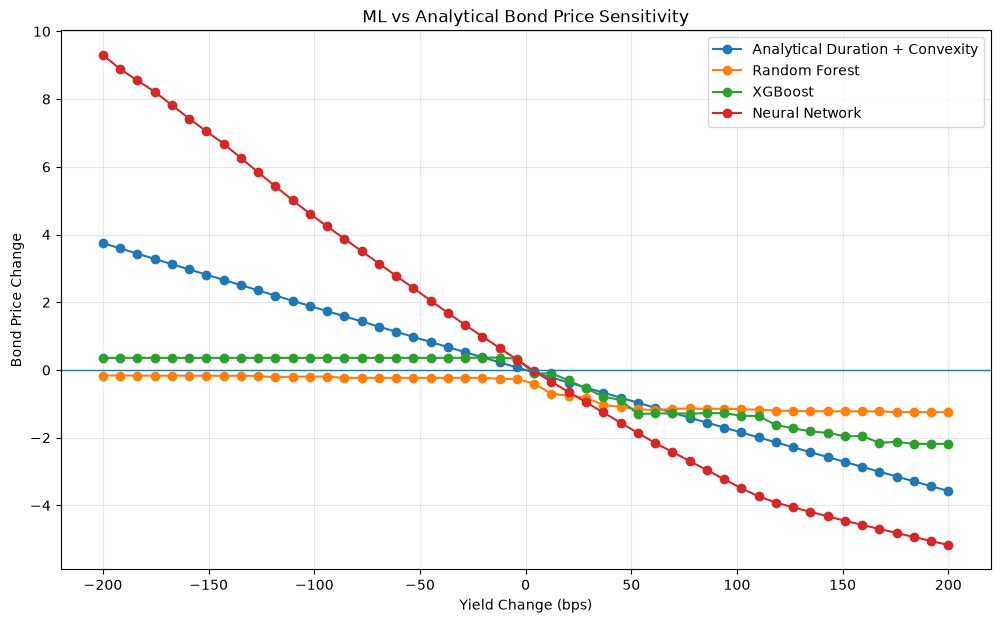

In [309]:
plt.figure(figsize=(12, 7))

plt.plot(
    day9_scenarios["Yield_Change_bps"],
    day9_scenarios["Analytical_Price_Change"],
    marker="o",
    label="Analytical Duration + Convexity"
)

plt.plot(
    day9_scenarios["Yield_Change_bps"],
    day9_scenarios["RF_Price_Change"],
    marker="o",
    label="Random Forest"
)

plt.plot(
    day9_scenarios["Yield_Change_bps"],
    day9_scenarios["XGB_Price_Change"],
    marker="o",
    label="XGBoost"
)

plt.plot(
    day9_scenarios["Yield_Change_bps"],
    day9_scenarios["NN_Price_Change"],
    marker="o",
    label="Neural Network"
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.xlabel("Yield Change (bps)")
plt.ylabel("Bond Price Change")
plt.title("ML vs Analytical Bond Price Sensitivity")

plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "../outputs/day9_ml_vs_analytical_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()                                                                              

In [310]:
import os

chart_path = "../outputs/day9_ml_vs_analytical_sensitivity.png"

if os.path.exists(chart_path):
    print("✓ Day 9 sensitivity chart saved successfully.")
else:
    print("✗ Chart was not saved.")

✓ Day 9 sensitivity chart saved successfully.


In [311]:
day9_scenarios.to_csv(
    "../outputs/day9_complete_sensitivity_results.csv",
    index=False
)

print("Complete Day 9 sensitivity dataset saved.")

Complete Day 9 sensitivity dataset saved.


In [312]:
day9_scenarios["RF_Divergence"] = np.abs(
    day9_scenarios["RF_Price_Change"]
    - day9_scenarios["Analytical_Price_Change"]
)

day9_scenarios["XGB_Divergence"] = np.abs(
    day9_scenarios["XGB_Price_Change"]
    - day9_scenarios["Analytical_Price_Change"]
)

day9_scenarios["NN_Divergence"] = np.abs(
    day9_scenarios["NN_Price_Change"]
    - day9_scenarios["Analytical_Price_Change"]
)

print("Divergence calculated successfully.")

Divergence calculated successfully.


In [313]:
display(
    day9_scenarios[
        [
            "Yield_Change_bps",
            "RF_Divergence",
            "XGB_Divergence",
            "NN_Divergence"
        ]
    ].round(4)
)

,Yield_Change_bps,RF_Divergence,XGB_Divergence,NN_Divergence
0,-200.0000,3.9114,3.3905,5.5537
1,-191.8367,3.7550,3.2341,5.2959
2,-183.6735,3.5989,3.0780,5.1136
3,-175.5102,3.4475,2.9222,4.9370
4,-167.3469,3.2920,2.7666,4.6966
5,-159.1837,3.1368,2.6114,4.4560
6,-151.0204,2.9818,2.4565,4.2332
7,-142.8571,2.8320,2.3018,4.0233
8,-134.6939,2.6750,2.1475,3.7548
9,-126.5306,2.5250,1.9934,3.4860


In [314]:
rf_max = day9_scenarios.loc[
    day9_scenarios["RF_Divergence"].idxmax()
]

xgb_max = day9_scenarios.loc[
    day9_scenarios["XGB_Divergence"].idxmax()
]

nn_max = day9_scenarios.loc[
    day9_scenarios["NN_Divergence"].idxmax()
]

print("Random Forest largest divergence:")
print(rf_max[["Yield_Change_bps", "RF_Divergence"]])

print("\nXGBoost largest divergence:")
print(xgb_max[["Yield_Change_bps", "XGB_Divergence"]])

print("\nNeural Network largest divergence:")
print(nn_max[["Yield_Change_bps", "NN_Divergence"]])

Random Forest largest divergence:
Yield_Change_bps   -200.000000
RF_Divergence         3.911408
Name: 0, dtype: float64

XGBoost largest divergence:
Yield_Change_bps   -200.000000
XGB_Divergence        3.390466
Name: 0, dtype: float64

Neural Network largest divergence:
Yield_Change_bps   -200.000000
NN_Divergence         5.553722
Name: 0, dtype: float64


In [315]:
average_divergence = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "Neural Network"
    ],
    "Average_Divergence": [
        day9_scenarios["RF_Divergence"].mean(),
        day9_scenarios["XGB_Divergence"].mean(),
        day9_scenarios["NN_Divergence"].mean()
    ]
})

display(average_divergence.round(4))

,Model,Average_Divergence
0,Random Forest,1.5147
1,XGBoost,1.0381
2,Neural Network,2.0441


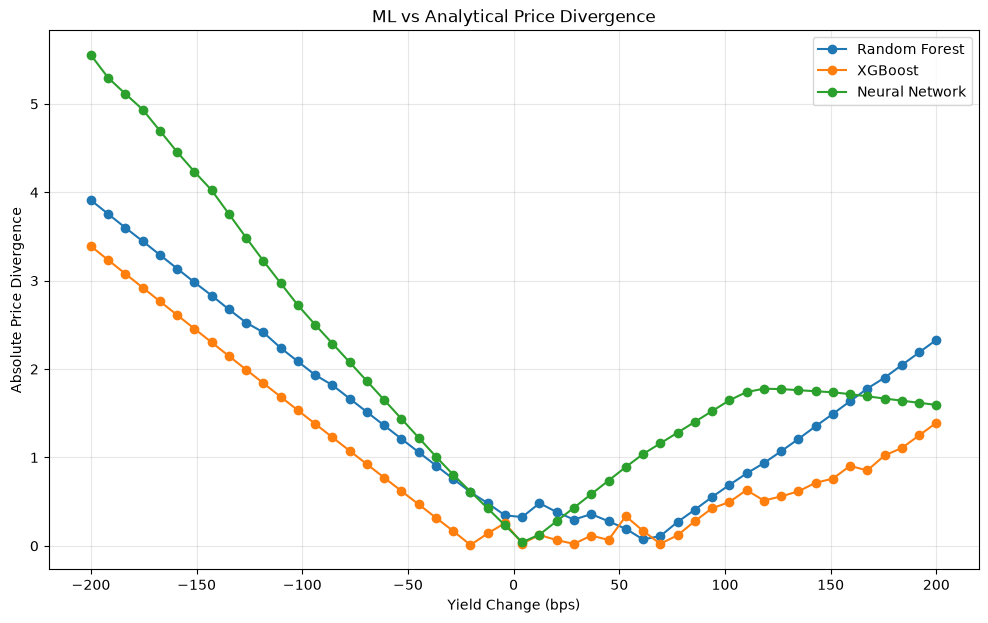

In [316]:
plt.figure(figsize=(12, 7))

plt.plot(
    day9_scenarios["Yield_Change_bps"],
    day9_scenarios["RF_Divergence"],
    marker="o",
    label="Random Forest"
)

plt.plot(
    day9_scenarios["Yield_Change_bps"],
    day9_scenarios["XGB_Divergence"],
    marker="o",
    label="XGBoost"
)

plt.plot(
    day9_scenarios["Yield_Change_bps"],
    day9_scenarios["NN_Divergence"],
    marker="o",
    label="Neural Network"
)

plt.xlabel("Yield Change (bps)")
plt.ylabel("Absolute Price Divergence")
plt.title("ML vs Analytical Price Divergence")

plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "../outputs/day9_ml_analytical_divergence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [317]:
day9_scenarios.to_csv(
    "../outputs/day9_divergence_results.csv",
    index=False
)

average_divergence.to_csv(
    "../outputs/day9_average_divergence.csv",
    index=False
)

print("Day 9 divergence results saved successfully.")

Day 9 divergence results saved successfully.


In [318]:
rf_weight = 1 / 3
xgb_weight = 1 / 3
nn_weight = 1 / 3

print("Random Forest weight:", rf_weight)
print("XGBoost weight:", xgb_weight)
print("Neural Network weight:", nn_weight)
print("Total weight:", rf_weight + xgb_weight + nn_weight)

Random Forest weight: 0.3333333333333333
XGBoost weight: 0.3333333333333333
Neural Network weight: 0.3333333333333333
Total weight: 1.0


In [319]:
day9_scenarios["Ensemble_Price"] = (
    rf_weight * day9_scenarios["RF_Price"]
    + xgb_weight * day9_scenarios["XGB_Price"]
    + nn_weight * day9_scenarios["NN_Price"]
)

print("Ensemble predictions created successfully.")

Ensemble predictions created successfully.


In [320]:
day9_scenarios["Ensemble_Price_Change"] = (
    day9_scenarios["Ensemble_Price"] - base_price
)

print("Ensemble price changes calculated successfully.")

Ensemble price changes calculated successfully.


In [321]:
display(
    day9_scenarios[
        [
            "Yield_Change_bps",
            "Analytical_Price_Change",
            "RF_Price_Change",
            "XGB_Price_Change",
            "NN_Price_Change",
            "Ensemble_Price_Change"
        ]
    ].round(4)
)

,Yield_Change_bps,Analytical_Price_Change,RF_Price_Change,XGB_Price_Change,NN_Price_Change,Ensemble_Price_Change
0,-200.0000,3.7480,-0.1634,0.3575,9.3017,3.1653
1,-191.8367,3.5916,-0.1634,0.3575,8.8875,3.0272
2,-183.6735,3.4355,-0.1634,0.3575,8.5491,2.9144
3,-175.5102,3.2797,-0.1678,0.3575,8.2166,2.8021
4,-167.3469,3.1242,-0.1678,0.3575,7.8208,2.6702
5,-159.1837,2.9689,-0.1678,0.3575,7.4249,2.5382
6,-151.0204,2.8140,-0.1678,0.3575,7.0472,2.4123
7,-142.8571,2.6593,-0.1727,0.3575,6.6826,2.2892
8,-134.6939,2.5050,-0.1700,0.3575,6.2598,2.1491
9,-126.5306,2.3509,-0.1740,0.3575,5.8369,2.0068


In [322]:
day9_scenarios["Ensemble_Divergence"] = np.abs(
    day9_scenarios["Ensemble_Price_Change"]
    - day9_scenarios["Analytical_Price_Change"]
)

print("Ensemble divergence calculated successfully.")

Ensemble divergence calculated successfully.


In [323]:
ensemble_average_divergence = (
    day9_scenarios["Ensemble_Divergence"].mean()
)

print(
    "Average Ensemble Divergence:",
    ensemble_average_divergence
)

Average Ensemble Divergence: 0.27840313451682397


In [324]:
day9_scenarios.to_csv(
    "../outputs/day9_ensemble_sensitivity_results.csv",
    index=False
)

print("Day 9 ensemble sensitivity results saved successfully.")

Day 9 ensemble sensitivity results saved successfully.


In [325]:
final_divergence_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "Neural Network",
        "Ensemble"
    ],
    "Average_Divergence": [
        day9_scenarios["RF_Divergence"].mean(),
        day9_scenarios["XGB_Divergence"].mean(),
        day9_scenarios["NN_Divergence"].mean(),
        day9_scenarios["Ensemble_Divergence"].mean()
    ]
})

final_divergence_comparison = (
    final_divergence_comparison
    .sort_values("Average_Divergence")
    .reset_index(drop=True)
)

display(final_divergence_comparison.round(4))

,Model,Average_Divergence
0,Ensemble,0.2784
1,XGBoost,1.0381
2,Random Forest,1.5147
3,Neural Network,2.0441


In [326]:
best_approach = final_divergence_comparison.loc[0, "Model"]
best_divergence = final_divergence_comparison.loc[
    0, "Average_Divergence"
]

print("Best approach:", best_approach)
print("Lowest average divergence:", best_divergence)

Best approach: Ensemble
Lowest average divergence: 0.27840313451682397


In [327]:
ensemble_divergence = day9_scenarios[
    "Ensemble_Divergence"
].mean()

individual_divergences = [
    day9_scenarios["RF_Divergence"].mean(),
    day9_scenarios["XGB_Divergence"].mean(),
    day9_scenarios["NN_Divergence"].mean()
]

best_individual_divergence = min(
    individual_divergences
)

print("Ensemble average divergence:",
      ensemble_divergence)

print("Best individual model divergence:",
      best_individual_divergence)

if ensemble_divergence < best_individual_divergence:
    print("✓ Ensemble outperforms all individual models.")
else:
    print("✓ An individual model performs better than the Ensemble.")

Ensemble average divergence: 0.27840313451682397
Best individual model divergence: 1.038104376679487
✓ Ensemble outperforms all individual models.


In [328]:
final_divergence_comparison.to_csv(
    "../outputs/day9_final_divergence_comparison.csv",
    index=False
)

print("Final Day 9 model comparison saved successfully.")

Final Day 9 model comparison saved successfully.


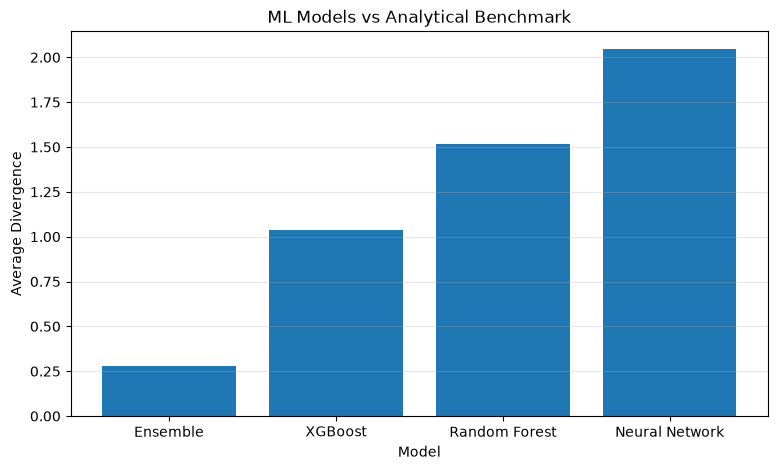

In [329]:
plt.figure(figsize=(9, 5))

plt.bar(
    final_divergence_comparison["Model"],
    final_divergence_comparison["Average_Divergence"]
)

plt.xlabel("Model")
plt.ylabel("Average Divergence")
plt.title("ML Models vs Analytical Benchmark")

plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "../outputs/day9_ensemble_vs_individual_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [334]:
print("======================================")
print("DAY 9 FINAL VALIDATION")
print("======================================")

print("Number of scenarios:", len(day9_scenarios))

DAY 9 FINAL VALIDATION
Number of scenarios: 50


In [335]:
print("RF predictions:", len(day9_scenarios["RF_Price"]))
print("XGB predictions:", len(day9_scenarios["XGB_Price"]))
print("NN predictions:", len(day9_scenarios["NN_Price"]))
print("Ensemble predictions:", len(day9_scenarios["Ensemble_Price"]))

RF predictions: 50
XGB predictions: 50
NN predictions: 50
Ensemble predictions: 50


In [336]:
display(
    final_divergence_comparison.round(4)
)

,Model,Average_Divergence
0,Ensemble,0.2784
1,XGBoost,1.0381
2,Random Forest,1.5147
3,Neural Network,2.0441


In [337]:
required_columns = [
    "Yield_Change_bps",
    "Analytical_Price",
    "RF_Price",
    "XGB_Price",
    "NN_Price",
    "Ensemble_Price",
    "Analytical_Price_Change",
    "RF_Price_Change",
    "XGB_Price_Change",
    "NN_Price_Change",
    "Ensemble_Price_Change",
    "RF_Divergence",
    "XGB_Divergence",
    "NN_Divergence",
    "Ensemble_Divergence"
]

missing_columns = [
    col for col in required_columns
    if col not in day9_scenarios.columns
]

if len(missing_columns) == 0:
    print("✓ All required Day 9 columns are present.")
else:
    print("✗ Missing columns:")
    print(missing_columns)

✓ All required Day 9 columns are present.
